# TikTok non-overlapping 3-year periods

This notebook adapts the Instagram 3-year pipeline to TikTok using two non-overlapping periods: `2020-2022` and `2023-2026-03`.

At this stage we only build the user-level variables, keep anyone with at least one top-level comment across the full analysis horizon, and inspect the resulting distributions before setting thresholds.

## Setup

The notebook is fully self-contained: all functions used by the TikTok pipeline are defined directly below, so the analysis does not depend on external Python modules.

This keeps the full workflow reproducible in a single notebook while still preserving a sectioned structure.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
from IPython.display import Image, display


candidate_dirs = [Path.cwd(), Path.cwd() / "Clustering Tk RFEC"]
OUTPUT_DIR = next(
    candidate
    for candidate in candidate_dirs
    if (candidate / "tk_non_overlapping_3y_periods_new_definitions.ipynb").exists()
)
DATA_DIR = OUTPUT_DIR.parent

COMMENTS_SOURCE = DATA_DIR / "tk_comments_clean.csv"
POSTS_SOURCE = DATA_DIR / "tk_posts_clean.csv"

METRICS_OUTPUT = OUTPUT_DIR / "tk_user_nonoverlapping_3y_periods_new_definitions.csv"
THRESHOLD_TABLE_OUTPUT = OUTPUT_DIR / "tk_nonoverlapping_3y_threshold_table.csv"
CLASSIFICATION_OUTPUT = OUTPUT_DIR / "tk_classification_nonoverlapping_3y.csv"
KMEDOIDS_K_SEARCH_OUTPUT = OUTPUT_DIR / "tk_kmedoids_k_search_nonoverlapping_3y.csv"
KMEDOIDS_DIAGNOSTIC_PLOT = OUTPUT_DIR / "tk_kmedoids_diagnostics_nonoverlapping_3y.png"
MACRO_CLUSTER_ASSIGNMENT_OUTPUT = OUTPUT_DIR / "tk_macro_cluster_assignment_nonoverlapping_3y.csv"
MACRO_CLUSTER_SUMMARY_OUTPUT = OUTPUT_DIR / "tk_macro_cluster_summary_nonoverlapping_3y.csv"
MACRO_CLUSTER_COUNTS_OUTPUT = OUTPUT_DIR / "tk_macro_cluster_counts_by_period_nonoverlapping_3y.csv"
MACRO_CLUSTER_SHARES_OUTPUT = OUTPUT_DIR / "tk_macro_cluster_shares_by_period_nonoverlapping_3y.csv"
MACRO_CLUSTER_BAR_PLOT = OUTPUT_DIR / "tk_macro_cluster_bar_by_period_nonoverlapping_3y.png"
MACRO_CLUSTER_PIE_PLOT = OUTPUT_DIR / "tk_macro_cluster_pie_by_period_nonoverlapping_3y.png"
PLOT_OUTPUT = OUTPUT_DIR / "tk_nonoverlapping_3y_period_distributions.png"

ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END_EXCLUSIVE = pd.Timestamp("2026-04-01")
MIN_COMMENTS_FULL_HORIZON = 1

COMMENT_DTYPES = {
    "cid": "string",
    "media_id": "string",
    "text": "string",
    "create_time": "string",
    "nickname": "string",
    "uid": "string",
    "reply_id": "string",
    "reply_to_reply_id": "string",
}

POST_DTYPES = {
    "media_id": "string",
    "creation_date": "string",
}

NON_EMOJI_TOKEN_RE = re.compile(
    r"https?://\S+|[#@]?\w+(?:[.'_-]\w+)*",
    flags=re.UNICODE,
)

EMOJI_RANGES = (
    (0x00A9, 0x00A9),
    (0x00AE, 0x00AE),
    (0x203C, 0x203C),
    (0x2049, 0x2049),
    (0x2122, 0x2122),
    (0x2139, 0x2139),
    (0x2194, 0x2199),
    (0x21A9, 0x21AA),
    (0x231A, 0x231B),
    (0x2328, 0x2328),
    (0x23CF, 0x23CF),
    (0x23E9, 0x23F3),
    (0x23F8, 0x23FA),
    (0x24C2, 0x24C2),
    (0x25AA, 0x25AB),
    (0x25B6, 0x25B6),
    (0x25C0, 0x25C0),
    (0x25FB, 0x25FE),
    (0x2600, 0x27BF),
    (0x2934, 0x2935),
    (0x2B05, 0x2B07),
    (0x2B1B, 0x2B1C),
    (0x2B50, 0x2B50),
    (0x2B55, 0x2B55),
    (0x3030, 0x3030),
    (0x303D, 0x303D),
    (0x3297, 0x3297),
    (0x3299, 0x3299),
    (0x1F000, 0x1FAFF),
)

EMOJI_CONNECTORS = {0x200D, 0x20E3, 0xFE0E, 0xFE0F}
KEYCAP_BASE_CHARS = set("0123456789#*")

PLOT_VARIABLES = [
    ("recency", "Recency"),
    ("coverage", "Coverage"),
    ("engagement", "Engagement"),
    ("gini", "Gini"),
]
PLOT_COLORS = ["#0B6E4F", "#C85C1A", "#3C4F76"]
THRESHOLD_VALUES = {
    "recency": (0.360996, 0.738589),
    "engagement": (6.0, 15.0),
    "gini": (0.2, 0.6),
}
PERIOD_SINGLE_THRESHOLDS = {
    "coverage": {
        "2020-2022": 0.011111,
        "2023-2026-03": 0.004149,
    },
}
THRESHOLD_COLORS = {
    "low": "#6A1B9A",
    "high": "#C62828",
}
PERIOD_THRESHOLD_LINESTYLES = {
    "2020-2022": (0, (6, 3)),
    "2023-2026-03": (0, (1, 2)),
}
PERIOD_THRESHOLD_COLOR = "#1F1F1F"
ZOOM_RANGES = {
    "coverage": (0.0, 0.03),
    "engagement": (0.0, 25.0),
}
MACRO_CLUSTER_COLORS = {
    "C1": "#1B998B",
    "C2": "#2D3047",
    "C3": "#FF9B71",
    "C4": "#A9BCD0",
}
CLASSIFICATION_VARIABLES = ["recency", "coverage", "engagement", "gini", "tenure_binary"]
PROFILE_LETTERS = {
    "recency": "R",
    "coverage": "C",
    "engagement": "E",
    "gini": "G",
    "tenure_binary": "T",
}
CLUSTER_VARIABLES = ["recency", "coverage", "engagement", "gini", "tenure_binary"]
LEVEL_COLUMNS = [f"{column}_level" for column in CLUSTER_VARIABLES]
LEVEL_VALUE_MAP = {
    "recency_level": {"Low": 0.0, "Mid": 0.5, "High": 1.0},
    "coverage_level": {"Low": 0.0, "High": 1.0},
    "engagement_level": {"Low": 0.0, "Mid": 0.5, "High": 1.0},
    "gini_level": {"Low": 0.0, "Mid": 0.5, "High": 1.0},
    "tenure_binary_level": {"Low": 0.0, "High": 1.0},
}
MIN_CLUSTER_SHARE_FOR_INTERPRETABILITY = 0.05
MIN_K_FOR_INTERPRETABILITY = 4
SIGNATURE_METADATA = {
    "Low-High-Low-Mid-High": {
        "cluster_name": "Emerging Advocates",
        "description": "Recent users with broad post coverage, moderate dispersion across posts, and a longer observed history. They look like the strongest community nucleus for loyalty and repeat interaction.",
    },
    "Low-Low-Mid-Low-Low": {
        "cluster_name": "Active Newcomers",
        "description": "Recent users with narrow coverage but more expressive comments. They are promising newer participants who already show richer interaction quality.",
    },
    "Mid-Low-Mid-Low-Low": {
        "cluster_name": "Conversational Browsers",
        "description": "Users of medium recency who still comment on few posts, but write more substantial comments when they do engage.",
    },
    "Low-Low-Low-Low-Low": {
        "cluster_name": "Fresh Touchpoints",
        "description": "Very recent but still light users: narrow coverage, short comments, low dispersion, and no longer observed history yet.",
    },
    "Mid-Low-Low-Low-Low": {
        "cluster_name": "Window Shoppers",
        "description": "Mid-recency, low-depth users who hover around the creator without developing broader or richer engagement.",
    },
    "High-Low-Low-Low-Low": {
        "cluster_name": "Cold Passersby",
        "description": "The coldest and lightest segment: least recent, narrow in coverage, brief in engagement, and without a durable observed relationship.",
    },
}
K8_MACRO_SIGNATURE_MAP = {
    "Low-High-Mid-High-High": {
        "macro_cluster": "C1",
        "cluster_name": "Brand Loyalists",
        "description": "Recent, broad, and persistent users with stronger expressive engagement and concentrated attention on a narrower set of posts. They are the clearest signs of a loyal brand-facing community nucleus.",
    },
    "Mid-High-Low-Mid-High": {
        "macro_cluster": "C2",
        "cluster_name": "Established Supporters",
        "description": "Less recent than the top cluster, but still broad in coverage and supported by a longer observed history. They look like a stable support base that returns over time, even if current activity is less intense.",
    },
    "Low-Low-Mid-Low-Low": {
        "macro_cluster": "C3",
        "cluster_name": "Conversational Occasionals",
        "description": "Users who comment on few posts but write more substantial comments when they do engage. Across the merged signatures, they mainly differ in recency rather than in the structure of their behavior.",
    },
    "Mid-Low-Mid-Low-Low": {
        "macro_cluster": "C3",
        "cluster_name": "Conversational Occasionals",
        "description": "Users who comment on few posts but write more substantial comments when they do engage. Across the merged signatures, they mainly differ in recency rather than in the structure of their behavior.",
    },
    "High-Low-Mid-Low-Low": {
        "macro_cluster": "C3",
        "cluster_name": "Conversational Occasionals",
        "description": "Users who comment on few posts but write more substantial comments when they do engage. Across the merged signatures, they mainly differ in recency rather than in the structure of their behavior.",
    },
    "Low-Low-Low-Low-Low": {
        "macro_cluster": "C4",
        "cluster_name": "Peripheral Audience",
        "description": "Light and low-value users with narrow coverage, low expressive engagement, and no longer observed history. The merged signatures differ mostly in recency, not in relational depth.",
    },
    "Mid-Low-Low-Low-Low": {
        "macro_cluster": "C4",
        "cluster_name": "Peripheral Audience",
        "description": "Light and low-value users with narrow coverage, low expressive engagement, and no longer observed history. The merged signatures differ mostly in recency, not in relational depth.",
    },
    "High-Low-Low-Low-Low": {
        "macro_cluster": "C4",
        "cluster_name": "Peripheral Audience",
        "description": "Light and low-value users with narrow coverage, low expressive engagement, and no longer observed history. The merged signatures differ mostly in recency, not in relational depth.",
    },
}
VALUE_SCORE_LOOKUP = {
    "recency_level": {"Low": 2, "Mid": 1, "High": 0},
    "coverage_level": {"Low": 0, "High": 3},
    "engagement_level": {"Low": 0, "Mid": 1, "High": 2},
    "gini_level": {"Low": 0, "Mid": 1, "High": 2},
    "tenure_binary_level": {"Low": 0, "High": 2},
}


@dataclass(frozen=True)
class PeriodSpec:
    period_id: str
    period_label: str
    period_index: int
    start: pd.Timestamp
    end: pd.Timestamp

    @property
    def end_exclusive(self) -> pd.Timestamp:
        return self.end + pd.Timedelta(days=1)

    @property
    def total_days(self) -> int:
        return int((self.end - self.start).days + 1)


## Build base inputs

We keep TikTok comments inside the full analysis range, retain only top-level comments, and apply the horizon-wide user filter once before building the period-level metrics.

In [2]:
def build_user_key(comments: pd.DataFrame) -> pd.Series:
    uid = comments["uid"].fillna("").astype("string").str.strip()
    uid = uid.mask(uid == "")
    nickname = comments["nickname"].fillna("").astype("string").str.strip().str.casefold()
    return uid.fillna("nickname:" + nickname)


def is_emojiish_char(char: str) -> bool:
    if not char:
        return False
    codepoint = ord(char)
    if any(start <= codepoint <= end for start, end in EMOJI_RANGES):
        return True
    category = unicodedata.category(char)
    return category == "So"


def is_regional_indicator(codepoint: int) -> bool:
    return 0x1F1E6 <= codepoint <= 0x1F1FF


def is_skin_tone_modifier(codepoint: int) -> bool:
    return 0x1F3FB <= codepoint <= 0x1F3FF


def is_emoji_base_char(char: str) -> bool:
    if not char:
        return False
    codepoint = ord(char)
    if char in KEYCAP_BASE_CHARS:
        return True
    if is_regional_indicator(codepoint) or is_skin_tone_modifier(codepoint):
        return True
    return is_emojiish_char(char)


def is_combining_or_extender(char: str) -> bool:
    if not char:
        return False
    codepoint = ord(char)
    return (
        unicodedata.combining(char) != 0
        or codepoint in EMOJI_CONNECTORS
        or is_skin_tone_modifier(codepoint)
    )


def consume_keycap_sequence(value: str, start: int) -> int | None:
    if value[start] not in KEYCAP_BASE_CHARS:
        return None
    end = start + 1
    while end < len(value) and ord(value[end]) in {0xFE0E, 0xFE0F}:
        end += 1
    if end < len(value) and ord(value[end]) == 0x20E3:
        return end + 1
    return None


def consume_emoji_cluster(value: str, start: int) -> tuple[str, int] | None:
    keycap_end = consume_keycap_sequence(value, start)
    if keycap_end is not None:
        return value[start:keycap_end], keycap_end

    if not is_emoji_base_char(value[start]):
        return None

    end = start + 1
    while end < len(value) and is_combining_or_extender(value[end]):
        end += 1

    while end < len(value) and ord(value[end]) == 0x200D:
        next_index = end + 1
        if next_index >= len(value) or not is_emoji_base_char(value[next_index]):
            break
        end = next_index + 1
        while end < len(value) and is_combining_or_extender(value[end]):
            end += 1

    return value[start:end], end


def count_words_with_emoji(text: object) -> int:
    if pd.isna(text):
        return 0
    value = str(text).strip()
    if not value:
        return 0

    count = 0
    last_emoji_cluster: str | None = None
    non_emoji_chunk: list[str] = []

    def flush_non_emoji() -> int:
        nonlocal non_emoji_chunk
        if not non_emoji_chunk:
            return 0
        chunk = "".join(non_emoji_chunk)
        non_emoji_chunk = []
        return len(NON_EMOJI_TOKEN_RE.findall(chunk))

    index = 0
    while index < len(value):
        cluster = consume_emoji_cluster(value, index)
        if cluster is None:
            non_emoji_chunk.append(value[index])
            index += 1
            continue

        emoji_text, next_index = cluster
        count += flush_non_emoji()
        if emoji_text != last_emoji_cluster:
            count += 1
            last_emoji_cluster = emoji_text
        index = next_index

    count += flush_non_emoji()
    return count


def is_zeroish(series: pd.Series) -> pd.Series:
    return series.fillna("").astype("string").str.strip().isin(["", "0"])


def load_all_comments() -> pd.DataFrame:
    comments = pd.read_csv(COMMENTS_SOURCE, dtype=COMMENT_DTYPES, low_memory=False)
    create_time_numeric = pd.to_numeric(comments["create_time"], errors="coerce")
    comments["timestamp"] = pd.to_datetime(create_time_numeric, unit="s", errors="coerce")
    comments = comments.dropna(subset=["cid", "media_id", "timestamp"]).copy()
    comments["nickname"] = comments["nickname"].fillna("").astype("string").str.strip()
    comments["uid"] = comments["uid"].fillna("").astype("string").str.strip()
    comments["reply_id"] = comments["reply_id"].fillna("").astype("string").str.strip()
    comments["reply_to_reply_id"] = comments["reply_to_reply_id"].fillna("").astype("string").str.strip()
    comments["user_key"] = build_user_key(comments)
    return comments


def load_all_posts() -> pd.DataFrame:
    posts = pd.read_csv(POSTS_SOURCE, dtype=POST_DTYPES, low_memory=False)
    posts["timestamp"] = pd.to_datetime(posts["creation_date"], errors="coerce")
    posts = posts.dropna(subset=["media_id", "timestamp"]).copy()
    posts = posts.sort_values(["timestamp", "media_id"], kind="mergesort").drop_duplicates("media_id", keep="last")
    return posts


def build_base_inputs(save: bool = True) -> dict[str, pd.DataFrame]:
    all_comments = load_all_comments()
    all_posts = load_all_posts()

    all_comments["word_count"] = all_comments["text"].map(count_words_with_emoji).astype(int)
    wordful_comments = all_comments.loc[all_comments["word_count"] > 0].copy()

    analysis_posts = all_posts.loc[
        (all_posts["timestamp"] >= ANALYSIS_START) & (all_posts["timestamp"] < ANALYSIS_END_EXCLUSIVE)
    ].copy()
    eligible_media_ids = pd.Index(analysis_posts["media_id"].drop_duplicates())

    analysis_comments = wordful_comments.loc[
        (wordful_comments["timestamp"] >= ANALYSIS_START)
        & (wordful_comments["timestamp"] < ANALYSIS_END_EXCLUSIVE)
        & (wordful_comments["media_id"].isin(eligible_media_ids))
    ].copy()

    top_level_mask = is_zeroish(analysis_comments["reply_id"]) & is_zeroish(analysis_comments["reply_to_reply_id"])
    top_level_comments = analysis_comments.loc[top_level_mask].copy()
    top_level_comments = top_level_comments.sort_values(
        ["timestamp", "media_id", "cid"],
        kind="mergesort",
    ).reset_index(drop=True)

    horizon_user_comment_counts = top_level_comments.groupby("user_key", sort=False).size()
    keep_user_keys = horizon_user_comment_counts[horizon_user_comment_counts >= MIN_COMMENTS_FULL_HORIZON].index
    removed_user_keys = horizon_user_comment_counts[horizon_user_comment_counts < MIN_COMMENTS_FULL_HORIZON].index

    filtered_comments = top_level_comments.loc[top_level_comments["user_key"].isin(keep_user_keys)].copy()
    filtered_comments = filtered_comments.sort_values(
        ["timestamp", "media_id", "cid"],
        kind="mergesort",
    ).reset_index(drop=True)

    matched_posts = analysis_posts.loc[
        analysis_posts["media_id"].isin(filtered_comments["media_id"].drop_duplicates())
    ].copy()
    matched_posts = matched_posts.sort_values(["timestamp", "media_id"], kind="mergesort").reset_index(drop=True)

    base_summary = pd.DataFrame(
        [
            {
                "raw_comment_rows": int(len(all_comments)),
                "wordless_comment_rows_removed": int(len(all_comments) - len(wordful_comments)),
                "analysis_range_comment_rows": int(len(analysis_comments)),
                "reply_comment_rows_removed": int(len(analysis_comments) - len(top_level_comments)),
                "top_level_comment_rows_before_horizon_filter": int(len(top_level_comments)),
                "top_level_users_before_horizon_filter": int(top_level_comments["user_key"].nunique()),
                "minimum_comments_required_full_horizon": int(MIN_COMMENTS_FULL_HORIZON),
                "users_removed_below_full_horizon_minimum": int(len(removed_user_keys)),
                "comments_removed_below_full_horizon_minimum": int(horizon_user_comment_counts.loc[removed_user_keys].sum()),
                "top_level_comment_rows_retained": int(len(filtered_comments)),
                "top_level_users_retained": int(filtered_comments["user_key"].nunique()),
                "posts_in_analysis_range": int(len(analysis_posts)),
                "posts_with_top_level_comments": int(matched_posts["media_id"].nunique()),
            }
        ]
    )

    return {
        "comments": filtered_comments,
        "posts": matched_posts,
        "summary": base_summary,
    }


In [3]:
base_bundle = build_base_inputs(save=True)
base_bundle["summary"]


,raw_comment_rows,wordless_comment_rows_removed,analysis_range_comment_rows,reply_comment_rows_removed,top_level_comment_rows_before_horizon_filter,top_level_users_before_horizon_filter,minimum_comments_required_full_horizon,users_removed_below_full_horizon_minimum,comments_removed_below_full_horizon_minimum,top_level_comment_rows_retained,top_level_users_retained,posts_in_analysis_range,posts_with_top_level_comments
0,19634,12,19622,0,19622,16190,1,0,0,19622,16190,335,331


## Compute period metrics

For each period we compute Recency, Coverage, Engagement, and Gini.

No additional user exclusion is applied inside the single periods. The table below only reports how many distinct users are active in each period after the horizon-wide preprocessing step.

In [4]:
def build_period_specs() -> list[PeriodSpec]:
    return [
        PeriodSpec("p1", "2020-2022", 1, pd.Timestamp("2020-01-01"), pd.Timestamp("2022-12-31")),
        PeriodSpec("p2", "2023-2026-03", 2, pd.Timestamp("2023-01-01"), pd.Timestamp("2026-03-31")),
    ]

TARGET_COLUMNS = [
    "period_id",
    "period_label",
    "period_index",
    "period_start",
    "period_end",
    "period_total_days",
    "posts_in_period",
    "user_key",
    "user_id",
    "username",
    "comment_count",
    "last_comment_timestamp",
    "tenure_binary",
    "recency",
    "coverage",
    "engagement",
    "gini",
]

def build_period_metrics(
    period: PeriodSpec,
    comments: pd.DataFrame,
    posts: pd.DataFrame,
    history: pd.DataFrame,
    first_comment_overall: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, object]]:
    posts_mask = (posts["timestamp"] >= period.start) & (posts["timestamp"] < period.end_exclusive)
    period_posts = posts.loc[posts_mask].copy()
    posts_in_period = int(len(period_posts))

    summary = {
        "period_id": period.period_id,
        "period_label": period.period_label,
        "period_index": period.period_index,
        "posts_in_period": posts_in_period,
        "users_with_at_least_one_comment_in_period": 0,
    }

    if posts_in_period == 0:
        return pd.DataFrame(columns=TARGET_COLUMNS), summary

    period_post_ids = pd.Index(period_posts["media_id"].drop_duplicates())
    comments_mask = (comments["timestamp"] >= period.start) & (comments["timestamp"] < period.end_exclusive)
    period_comments = comments.loc[comments_mask & comments["media_id"].isin(period_post_ids)].copy()
    if period_comments.empty:
        return pd.DataFrame(columns=TARGET_COLUMNS), summary

    summary["users_with_at_least_one_comment_in_period"] = int(period_comments["user_key"].nunique())

    period_comments = period_comments.sort_values(["user_key", "timestamp", "cid"], kind="mergesort").reset_index(drop=True)

    posts_seen = np.searchsorted(
        period_posts["timestamp"].to_numpy(dtype="datetime64[ns]"),
        period_comments["timestamp"].to_numpy(dtype="datetime64[ns]"),
        side="right",
    )
    period_comments["posts_seen_by_comment_time"] = posts_seen

    per_post_counts = (
        period_comments.groupby(["user_key", "media_id"], sort=False)
        .size()
        .rename("comments_on_post")
        .reset_index()
    )
    per_post_counts["comment_share"] = (
        per_post_counts["comments_on_post"] / per_post_counts.groupby("user_key")["comments_on_post"].transform("sum")
    )
    gini = (
        per_post_counts.assign(comment_share_sq=lambda df: np.square(df["comment_share"]))
        .groupby("user_key", sort=False)["comment_share_sq"]
        .sum()
        .rename("hhi")
        .reset_index()
    )
    gini["gini"] = 1 - gini["hhi"]

    latest_history = (
        history.loc[history["timestamp"] < period.end_exclusive, ["user_key", "timestamp"]]
        .groupby("user_key", sort=False)["timestamp"]
        .max()
        .rename("latest_history_comment")
        .reset_index()
    )

    aggregated = (
        period_comments.groupby("user_key", sort=False)
        .agg(
            user_id=("uid", "last"),
            username=("nickname", "last"),
            comment_count=("cid", "size"),
            distinct_posts_commented=("media_id", "nunique"),
            last_comment_timestamp=("timestamp", "max"),
            last_posts_seen=("posts_seen_by_comment_time", "last"),
            engagement=("word_count", "mean"),
        )
        .reset_index()
    )

    aggregated = aggregated.merge(gini[["user_key", "gini"]], on="user_key", how="left")
    aggregated = aggregated.merge(first_comment_overall, on="user_key", how="left")
    aggregated = aggregated.merge(latest_history, on="user_key", how="left")

    aggregated["tenure_binary"] = (
        aggregated["latest_history_comment"].gt(aggregated["first_comment_timestamp"])
    ).astype(int)
    aggregated["recency"] = (posts_in_period - aggregated["last_posts_seen"]) / posts_in_period
    aggregated["coverage"] = aggregated["distinct_posts_commented"] / posts_in_period

    aggregated["period_id"] = period.period_id
    aggregated["period_label"] = period.period_label
    aggregated["period_index"] = period.period_index
    aggregated["period_start"] = period.start.date().isoformat()
    aggregated["period_end"] = period.end.date().isoformat()
    aggregated["period_total_days"] = period.total_days
    aggregated["posts_in_period"] = posts_in_period

    metrics = aggregated[TARGET_COLUMNS].copy()
    for column in ["recency", "coverage", "engagement", "gini"]:
        metrics[column] = metrics[column].round(6)

    return metrics, summary


def compute_period_metrics(
    base_comments: pd.DataFrame | None = None,
    base_posts: pd.DataFrame | None = None,
    save: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if base_comments is None or base_posts is None:
        base_bundle = build_base_inputs(save=save)
        base_comments = base_bundle["comments"]
        base_posts = base_bundle["posts"]

    comments = base_comments.copy()
    posts = base_posts.copy()
    comments["timestamp"] = pd.to_datetime(comments["timestamp"], errors="coerce")
    posts["timestamp"] = pd.to_datetime(posts["timestamp"], errors="coerce")

    first_comment_overall = (
        comments.groupby("user_key", sort=False)["timestamp"]
        .min()
        .rename("first_comment_timestamp")
        .reset_index()
    )

    metrics_frames: list[pd.DataFrame] = []
    filter_rows: list[dict[str, object]] = []
    for period in build_period_specs():
        metrics_frame, summary = build_period_metrics(
            period=period,
            comments=comments,
            posts=posts,
            history=comments,
            first_comment_overall=first_comment_overall,
        )
        metrics_frames.append(metrics_frame)
        filter_rows.append(summary)

    metrics = pd.concat(metrics_frames, ignore_index=True) if metrics_frames else pd.DataFrame(columns=TARGET_COLUMNS)
    filter_summary = pd.DataFrame(filter_rows).sort_values("period_index").reset_index(drop=True)

    if save:
        metrics.to_csv(METRICS_OUTPUT, index=False, encoding="utf-8-sig")

    return metrics, filter_summary


def estimate_bandwidth(values: np.ndarray, multiplier: float = 1.0) -> float:
    if values.size <= 1:
        return 1.0
    sample_std = float(np.std(values, ddof=1))
    iqr = float(np.subtract(*np.percentile(values, [75, 25])))
    scale = min(sample_std, iqr / 1.34) if iqr > 0 else sample_std
    if not np.isfinite(scale) or scale <= 0:
        scale = sample_std if np.isfinite(sample_std) and sample_std > 0 else 1.0
    bandwidth = 0.9 * scale * (values.size ** (-1 / 5))
    return max(bandwidth * multiplier, 1e-3)


def gaussian_kde_on_grid(values: np.ndarray, grid: np.ndarray, multiplier: float = 1.0) -> np.ndarray:
    if values.size == 0:
        return np.zeros_like(grid)
    bandwidth = estimate_bandwidth(values, multiplier=multiplier)
    scaled = (grid[:, None] - values[None, :]) / bandwidth
    kernel = np.exp(-0.5 * np.square(scaled)) / np.sqrt(2 * np.pi)
    return kernel.mean(axis=1) / bandwidth


def summarize_metrics(metrics: pd.DataFrame, save: bool = True) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for period in metrics[["period_label", "period_index"]].drop_duplicates().sort_values("period_index").itertuples(index=False):
        subset = metrics.loc[metrics["period_label"] == period.period_label]
        for column, label in PLOT_VARIABLES:
            values = subset[column].dropna().to_numpy(dtype=float)
            if values.size == 0:
                continue
            rows.append(
                {
                    "period_label": period.period_label,
                    "period_index": period.period_index,
                    "metric": column,
                    "metric_label": label,
                    "count": int(values.size),
                    "mean": float(np.mean(values)),
                    "median": float(np.median(values)),
                    "p10": float(np.percentile(values, 10)),
                    "p25": float(np.percentile(values, 25)),
                    "p75": float(np.percentile(values, 75)),
                    "p90": float(np.percentile(values, 90)),
                }
            )

    summary_df = pd.DataFrame(rows)
    return summary_df


def build_threshold_table(metrics: pd.DataFrame | None = None, save: bool = True) -> pd.DataFrame:
    if metrics is None:
        metrics = pd.read_csv(METRICS_OUTPUT, low_memory=False)

    rows = []
    for metric, (low_threshold, high_threshold) in THRESHOLD_VALUES.items():
        label = next(plot_label for column, plot_label in PLOT_VARIABLES if column == metric)
        rows.append(
            {
                "metric": metric,
                "metric_label": label,
                "period_label": pd.NA,
                "period_index": pd.NA,
                "threshold_scope": "global",
                "threshold_kind": "low_high",
                "low_threshold": float(low_threshold),
                "high_threshold": float(high_threshold),
                "single_threshold": pd.NA,
            }
        )

    period_lookup = (
        metrics[["period_label", "period_index"]]
        .drop_duplicates()
        .sort_values("period_index")
        .reset_index(drop=True)
    )
    period_index_map = dict(zip(period_lookup["period_label"], period_lookup["period_index"]))

    for metric, threshold_spec in PERIOD_SINGLE_THRESHOLDS.items():
        label = next(plot_label for column, plot_label in PLOT_VARIABLES if column == metric)
        if isinstance(threshold_spec, dict):
            threshold_map = threshold_spec
        else:
            percentile = float(threshold_spec)
            period_thresholds = (
                metrics.groupby(["period_label", "period_index"], sort=False)[metric]
                .quantile(percentile)
                .reset_index()
                .rename(columns={metric: "single_threshold"})
            )
            threshold_map = {
                row.period_label: float(row.single_threshold)
                for row in period_thresholds.itertuples(index=False)
            }

        for period_label, single_threshold in threshold_map.items():
            metric_values = metrics.loc[metrics["period_label"] == period_label, metric].dropna().to_numpy(dtype=float)
            percentile_rank = float(np.mean(metric_values <= single_threshold)) if metric_values.size else float("nan")
            rows.append(
                {
                    "metric": metric,
                    "metric_label": label,
                    "period_label": period_label,
                    "period_index": period_index_map.get(period_label, pd.NA),
                    "threshold_scope": "period_specific",
                    "threshold_kind": "single",
                    "requested_percentile": float(threshold_spec) if not isinstance(threshold_spec, dict) else pd.NA,
                    "low_threshold": pd.NA,
                    "high_threshold": pd.NA,
                    "single_threshold": float(single_threshold),
                    "approx_percentile_rank": percentile_rank,
                }
            )

    threshold_df = pd.DataFrame(rows)
    if save:
        threshold_df.to_csv(THRESHOLD_TABLE_OUTPUT, index=False, encoding="utf-8-sig")
    return threshold_df




def summarize_tenure_binary(metrics: pd.DataFrame, save: bool = True) -> pd.DataFrame:
    counts = (
        metrics.groupby(["period_label", "period_index", "tenure_binary"], sort=False)
        .size()
        .rename("count")
        .reset_index()
    )
    counts["share_within_period"] = counts["count"] / counts.groupby(
        ["period_label", "period_index"], sort=False
    )["count"].transform("sum")
    counts["tenure_binary_level"] = counts["tenure_binary"].map({0: "Low", 1: "High"})

    summary = (
        counts.pivot_table(
            index=["period_label", "period_index"],
            columns="tenure_binary_level",
            values="share_within_period",
            aggfunc="first",
        )
        .rename(columns={"Low": "tenure_binary_low_share", "High": "tenure_binary_high_share"})
        .reset_index()
        .fillna(0.0)
        .sort_values("period_index")
        .reset_index(drop=True)
    )
    return summary


In [5]:
metrics, filter_summary = compute_period_metrics(
    base_comments=base_bundle["comments"],
    base_posts=base_bundle["posts"],
    save=True,
)
filter_summary


,period_id,period_label,period_index,posts_in_period,users_with_at_least_one_comment_in_period
0,p1,2020-2022,1,90,4433
1,p2,2023-2026-03,2,241,11946


## Binary tenure proxy

For TikTok we keep a binary version of the tenure idea instead of the continuous variable.

- `tenure_binary = 0` means the user still has only one observed comment by the end of that period.
- `tenure_binary = 1` means the user has a longer observed history by the end of that period.

Because this variable is discrete, we inspect it inside the combined distribution figure with a dedicated discrete panel instead of treating it like a continuous density.

In [6]:
summarize_tenure_binary(metrics, save=True)


tenure_binary_level,period_label,period_index,tenure_binary_high_share,tenure_binary_low_share
0,2020-2022,1,0.089781,0.910219
1,2023-2026-03,2,0.142223,0.857777


## Plot period distributions

We compare the two non-overlapping periods in a small-multiple density grid and overlay the selected thresholds for each metric.

The threshold lines use colors distinct from the period curves so the triennia remain visually separate.

Coverage uses one period-specific threshold per triennium, set to the value corresponding to exactly one commented post in that period, because the creator's posting volume differs substantially across the two triennia.

In [7]:
def estimate_bandwidth(values: np.ndarray, multiplier: float = 1.0) -> float:
    if values.size <= 1:
        return 1.0
    sample_std = float(np.std(values, ddof=1))
    iqr = float(np.subtract(*np.percentile(values, [75, 25])))
    scale = min(sample_std, iqr / 1.34) if iqr > 0 else sample_std
    if not np.isfinite(scale) or scale <= 0:
        scale = sample_std if np.isfinite(sample_std) and sample_std > 0 else 1.0
    bandwidth = 0.9 * scale * (values.size ** (-1 / 5))
    return max(bandwidth * multiplier, 1e-3)


def gaussian_kde_on_grid(values: np.ndarray, grid: np.ndarray, multiplier: float = 1.0) -> np.ndarray:
    if values.size == 0:
        return np.zeros_like(grid)
    bandwidth = estimate_bandwidth(values, multiplier=multiplier)
    scaled = (grid[:, None] - values[None, :]) / bandwidth
    kernel = np.exp(-0.5 * np.square(scaled)) / np.sqrt(2 * np.pi)
    return kernel.mean(axis=1) / bandwidth


def summarize_metrics(metrics: pd.DataFrame, save: bool = True) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for period in metrics[["period_label", "period_index"]].drop_duplicates().sort_values("period_index").itertuples(index=False):
        subset = metrics.loc[metrics["period_label"] == period.period_label]
        for column, label in PLOT_VARIABLES:
            values = subset[column].dropna().to_numpy(dtype=float)
            if values.size == 0:
                continue
            rows.append(
                {
                    "period_label": period.period_label,
                    "period_index": period.period_index,
                    "metric": column,
                    "metric_label": label,
                    "count": int(values.size),
                    "mean": float(np.mean(values)),
                    "median": float(np.median(values)),
                    "p10": float(np.percentile(values, 10)),
                    "p25": float(np.percentile(values, 25)),
                    "p75": float(np.percentile(values, 75)),
                    "p90": float(np.percentile(values, 90)),
                }
            )

    summary_df = pd.DataFrame(rows)
    return summary_df


def build_threshold_table(metrics: pd.DataFrame | None = None, save: bool = True) -> pd.DataFrame:
    if metrics is None:
        metrics = pd.read_csv(METRICS_OUTPUT, low_memory=False)

    rows = []
    for metric, (low_threshold, high_threshold) in THRESHOLD_VALUES.items():
        label = next(plot_label for column, plot_label in PLOT_VARIABLES if column == metric)
        rows.append(
            {
                "metric": metric,
                "metric_label": label,
                "period_label": pd.NA,
                "period_index": pd.NA,
                "threshold_scope": "global",
                "threshold_kind": "low_high",
                "low_threshold": float(low_threshold),
                "high_threshold": float(high_threshold),
                "single_threshold": pd.NA,
            }
        )

    period_lookup = (
        metrics[["period_label", "period_index"]]
        .drop_duplicates()
        .sort_values("period_index")
        .reset_index(drop=True)
    )
    period_index_map = dict(zip(period_lookup["period_label"], period_lookup["period_index"]))

    for metric, threshold_spec in PERIOD_SINGLE_THRESHOLDS.items():
        label = next(plot_label for column, plot_label in PLOT_VARIABLES if column == metric)
        if isinstance(threshold_spec, dict):
            threshold_map = threshold_spec
        else:
            percentile = float(threshold_spec)
            period_thresholds = (
                metrics.groupby(["period_label", "period_index"], sort=False)[metric]
                .quantile(percentile)
                .reset_index()
                .rename(columns={metric: "single_threshold"})
            )
            threshold_map = {
                row.period_label: float(row.single_threshold)
                for row in period_thresholds.itertuples(index=False)
            }

        for period_label, single_threshold in threshold_map.items():
            metric_values = metrics.loc[metrics["period_label"] == period_label, metric].dropna().to_numpy(dtype=float)
            percentile_rank = float(np.mean(metric_values <= single_threshold)) if metric_values.size else float("nan")
            rows.append(
                {
                    "metric": metric,
                    "metric_label": label,
                    "period_label": period_label,
                    "period_index": period_index_map.get(period_label, pd.NA),
                    "threshold_scope": "period_specific",
                    "threshold_kind": "single",
                    "requested_percentile": float(threshold_spec) if not isinstance(threshold_spec, dict) else pd.NA,
                    "low_threshold": pd.NA,
                    "high_threshold": pd.NA,
                    "single_threshold": float(single_threshold),
                    "approx_percentile_rank": percentile_rank,
                }
            )

    threshold_df = pd.DataFrame(rows)
    if save:
        threshold_df.to_csv(THRESHOLD_TABLE_OUTPUT, index=False, encoding="utf-8-sig")
    return threshold_df

def plot_period_distributions(metrics: pd.DataFrame, save: bool = True) -> pd.DataFrame:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    if metrics.empty:
        raise ValueError("Metrics table is empty; nothing to plot.")

    summary_df = summarize_metrics(metrics, save=save)
    threshold_table = build_threshold_table(metrics, save=save)
    tenure_binary_summary = summarize_tenure_binary(metrics, save=save)
    plot_periods = (
        metrics[["period_label", "period_index"]]
        .drop_duplicates()
        .sort_values("period_index")
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.subplots_adjust(top=0.84, wspace=0.24, hspace=0.34)
    axes = axes.ravel()

    for axis, (column, label) in zip(axes, PLOT_VARIABLES):
        all_values = metrics[column].dropna().to_numpy(dtype=float)
        if all_values.size == 0:
            axis.set_visible(False)
            continue

        x_min = float(all_values.min())
        x_max = float(all_values.max())
        padding = 0.06 * (x_max - x_min) if x_max > x_min else max(abs(x_min) * 0.1, 1.0)
        lower = x_min - padding
        upper = x_max + padding
        if column in ZOOM_RANGES:
            lower, upper = ZOOM_RANGES[column]
        grid = np.linspace(lower, upper, 512)

        for color, period_row in zip(PLOT_COLORS, plot_periods.itertuples(index=False)):
            values = metrics.loc[metrics["period_label"] == period_row.period_label, column].dropna().to_numpy(dtype=float)
            if values.size == 0:
                continue
            density = gaussian_kde_on_grid(values, grid, multiplier=1.0)
            axis.plot(grid, density, linewidth=2.2, color=color, label=period_row.period_label)

        if column in PERIOD_SINGLE_THRESHOLDS:
            period_thresholds = (
                threshold_table.loc[threshold_table["metric"] == column]
                .sort_values("period_index")
                .reset_index(drop=True)
            )
            threshold_lines = []
            for row in period_thresholds.itertuples(index=False):
                linestyle = PERIOD_THRESHOLD_LINESTYLES.get(row.period_label, (0, (6, 3)))
                axis.axvline(
                    row.single_threshold,
                    color=PERIOD_THRESHOLD_COLOR,
                    linewidth=2.0,
                    linestyle=linestyle,
                    alpha=0.95,
                )
                threshold_lines.append(
                    f"{row.period_label}: threshold={row.single_threshold:.3f}"
                )
            axis.text(
                0.98,
                0.98,
                "\n".join(threshold_lines),
                transform=axis.transAxes,
                ha="right",
                va="top",
                fontsize=8.5,
                bbox={"facecolor": "white", "alpha": 0.82, "edgecolor": "#CCCCCC", "boxstyle": "round,pad=0.25"},
            )
        else:
            low_threshold, high_threshold = THRESHOLD_VALUES[column]
            axis.axvline(
                low_threshold,
                color=THRESHOLD_COLORS["low"],
                linewidth=2.0,
                linestyle=(0, (6, 3)),
                alpha=0.95,
            )
            axis.axvline(
                high_threshold,
                color=THRESHOLD_COLORS["high"],
                linewidth=2.0,
                linestyle=(0, (2, 3)),
                alpha=0.95,
            )

        axis.set_title(f"{label} (period-specific threshold)" if column in PERIOD_SINGLE_THRESHOLDS else label)
        axis.set_xlabel(label)
        axis.set_ylabel("Density")
        axis.grid(alpha=0.2, linewidth=0.6)
        axis.set_xlim(lower, upper)

    tenure_axis = axes[len(PLOT_VARIABLES)]
    plot_df = (
        tenure_binary_summary[["period_label", "period_index", "tenure_binary_low_share", "tenure_binary_high_share"]]
        .rename(columns={"tenure_binary_low_share": "0", "tenure_binary_high_share": "1"})
        .melt(id_vars=["period_label", "period_index"], var_name="tenure_binary", value_name="share")
    )
    period_order = tenure_binary_summary.sort_values("period_index")["period_label"].tolist()
    binary_order = ["0", "1"]
    x_positions = np.arange(len(binary_order))
    bar_width = 0.34
    offsets = np.linspace(-bar_width / 2, bar_width / 2, num=len(period_order))
    for offset, period_label, color in zip(offsets, period_order, PLOT_COLORS):
        subset = plot_df.loc[plot_df["period_label"] == period_label].set_index("tenure_binary").reindex(binary_order)
        bars = tenure_axis.bar(
            x_positions + offset,
            subset["share"].to_numpy(dtype=float),
            width=bar_width,
            color=color,
            alpha=0.92,
        )
        for bar in bars:
            height = float(bar.get_height())
            tenure_axis.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.012,
                f"{height:.1%}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    tenure_axis.set_xticks(x_positions)
    tenure_axis.set_xticklabels(
        [
            "0\nonly one observed\ncomment by period end",
            "1\nmore than one observed\ncomment by period end",
        ]
    )
    tenure_axis.set_ylim(0, 1.0)
    tenure_axis.set_ylabel("Share of user-period rows")
    tenure_axis.set_title("tenure_binary (discrete)")
    tenure_axis.grid(axis="y", alpha=0.2, linewidth=0.6)
    tenure_axis.set_axisbelow(True)

    for axis in axes[len(PLOT_VARIABLES) + 1:]:
        axis.set_visible(False)

    period_handles, period_labels = axes[0].get_legend_handles_labels()
    threshold_handles = [
        plt.Line2D([0], [0], color=THRESHOLD_COLORS["low"], linewidth=2.0, linestyle=(0, (6, 3)), label="Low threshold"),
        plt.Line2D([0], [0], color=THRESHOLD_COLORS["high"], linewidth=2.0, linestyle=(0, (2, 3)), label="High threshold"),
        plt.Line2D([0], [0], color=PERIOD_THRESHOLD_COLOR, linewidth=2.0, linestyle=PERIOD_THRESHOLD_LINESTYLES["2020-2022"], label="Coverage threshold 2020-2022"),
        plt.Line2D([0], [0], color=PERIOD_THRESHOLD_COLOR, linewidth=2.0, linestyle=PERIOD_THRESHOLD_LINESTYLES["2023-2026-03"], label="Coverage threshold 2023-2026-03"),
    ]
    fig.suptitle("TikTok metric distributions with candidate thresholds", fontsize=16, y=0.98)
    fig.legend(period_handles, period_labels, loc="upper center", ncol=max(len(period_labels), 1), frameon=False, bbox_to_anchor=(0.22, 0.93))
    fig.legend(
        threshold_handles,
        ["Low threshold", "High threshold", "Coverage threshold 2020-2022", "Coverage threshold 2023-2026-03"],
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.72, 0.93),
    )

    if save:
        fig.savefig(PLOT_OUTPUT, dpi=220, bbox_inches="tight")
    plt.close(fig)

    return summary_df


In [8]:
build_threshold_table(metrics, save=True)


,metric,metric_label,period_label,period_index,threshold_scope,threshold_kind,low_threshold,high_threshold,single_threshold,requested_percentile,approx_percentile_rank
0,recency,Recency,NaN,<NA>,global,low_high,0.360996,0.738589,<NA>,NaN,NaN
1,engagement,Engagement,NaN,<NA>,global,low_high,6.0,15.0,<NA>,NaN,NaN
2,gini,Gini,NaN,<NA>,global,low_high,0.2,0.6,<NA>,NaN,NaN
3,coverage,Coverage,2020-2022,1,period_specific,single,<NA>,<NA>,0.011111,<NA>,0.916986
4,coverage,Coverage,2023-2026-03,2,period_specific,single,<NA>,<NA>,0.004149,<NA>,0.895614


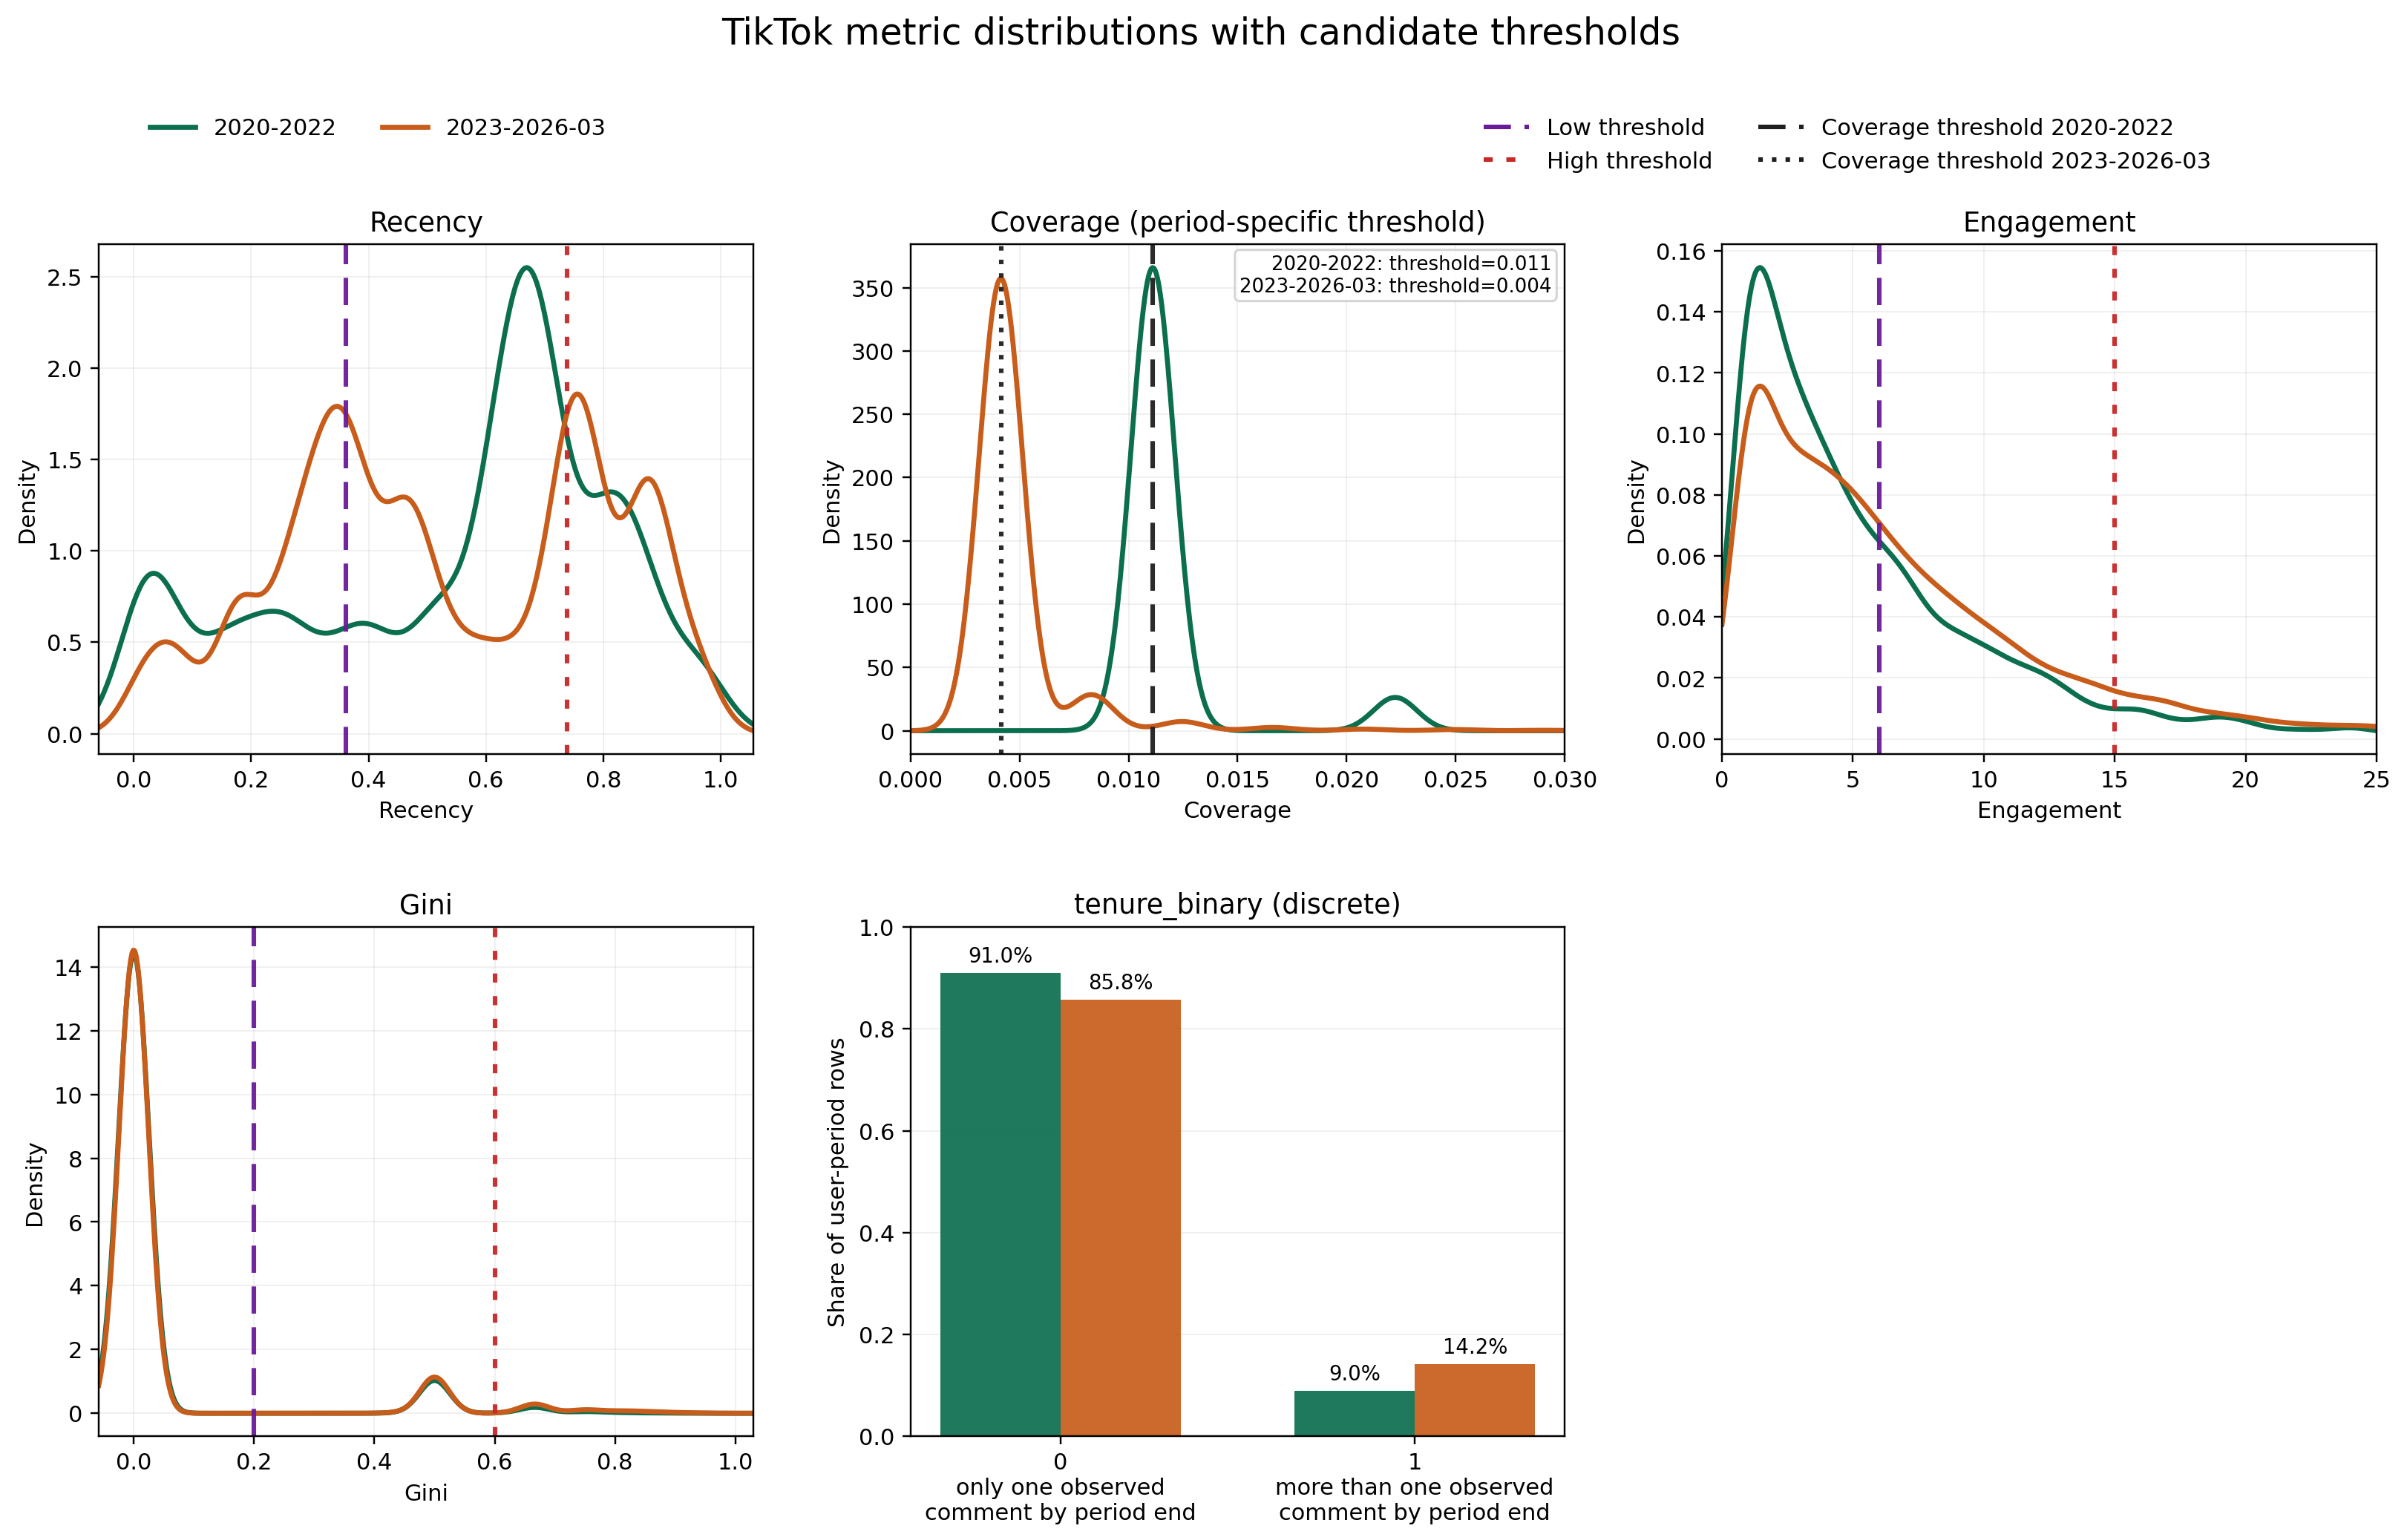

In [9]:
metric_summary = plot_period_distributions(metrics, save=True)
display(Image(filename=str(PLOT_OUTPUT)))


## Classify User-Period Profiles

We now convert the continuous and discrete variables into categorical levels for downstream clustering and interpretation.

- `recency`, `engagement`, and `gini` use `Low / Mid / High`.
- `coverage` uses `Low / High` with the period-specific threshold derived from one commented post in the relevant triennium.
- `tenure_binary` uses `Low / High` directly from the binary flag.

In [10]:
def assign_three_level(value: float, low_threshold: float, high_threshold: float) -> object:
    if pd.isna(value):
        return pd.NA
    if value <= low_threshold:
        return "Low"
    if value <= high_threshold:
        return "Mid"
    return "High"


def assign_two_level(value: float, threshold: float) -> object:
    if pd.isna(value):
        return pd.NA
    return "Low" if value <= threshold else "High"


def assign_binary_flag_level(value: object) -> object:
    if pd.isna(value):
        return pd.NA
    return "Low" if int(value) == 0 else "High"


def build_classification(
    metrics: pd.DataFrame | None = None,
    threshold_table: pd.DataFrame | None = None,
    save: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if metrics is None:
        metrics = pd.read_csv(METRICS_OUTPUT, low_memory=False)
    if threshold_table is None:
        threshold_table = build_threshold_table(metrics, save=save)

    classification = metrics.copy()

    for column in ["recency", "engagement", "gini"]:
        low_threshold, high_threshold = THRESHOLD_VALUES[column]
        classification[f"{column}_low_threshold"] = low_threshold
        classification[f"{column}_high_threshold"] = high_threshold
        classification[f"{column}_level"] = classification[column].map(
            lambda value, low=low_threshold, high=high_threshold: assign_three_level(value, low, high)
        )

    coverage_thresholds = (
        threshold_table.loc[threshold_table["metric"] == "coverage", ["period_label", "single_threshold"]]
        .rename(columns={"single_threshold": "coverage_threshold"})
        .copy()
    )
    classification = classification.merge(coverage_thresholds, on="period_label", how="left")
    classification["coverage_level"] = classification.apply(
        lambda row: assign_two_level(row["coverage"], row["coverage_threshold"]),
        axis=1,
    )

    classification["tenure_binary_level"] = classification["tenure_binary"].map(assign_binary_flag_level)

    classification["tk_profile"] = classification.apply(
        lambda row: " | ".join(
            f"{PROFILE_LETTERS[column]}={row[f'{column}_level']}" for column in CLASSIFICATION_VARIABLES
        ),
        axis=1,
    )

    summary = (
        classification.melt(
            id_vars=["period_label", "period_index"],
            value_vars=[f"{column}_level" for column in CLASSIFICATION_VARIABLES],
            var_name="metric_level_column",
            value_name="level",
        )
        .assign(metric=lambda df: df["metric_level_column"].str.replace("_level", "", regex=False))
        .groupby(["period_label", "period_index", "metric", "level"], sort=False)
        .size()
        .rename("count")
        .reset_index()
    )
    summary["share_within_metric_period"] = summary["count"] / summary.groupby(
        ["period_label", "metric"], sort=False
    )["count"].transform("sum")

    if save:
        classification.to_csv(CLASSIFICATION_OUTPUT, index=False, encoding="utf-8-sig")

    return classification, summary


In [11]:
classification, classification_summary = build_classification(metrics, save=True)
classification.head()


,period_id,period_label,period_index,period_start,period_end,period_total_days,posts_in_period,user_key,user_id,username,...,engagement_low_threshold,engagement_high_threshold,engagement_level,gini_low_threshold,gini_high_threshold,gini_level,coverage_threshold,coverage_level,tenure_binary_level,tk_profile
0,p1,2020-2022,1,2020-01-01,2022-12-31,1096,90,100627184523882496,100627184523882496,Fernandofossa,...,6.0,15.0,Low,0.2,0.6,Low,0.011111,Low,Low,R=High | C=Low | E=Low | G=Low | T=Low
1,p1,2020-2022,1,2020-01-01,2022-12-31,1096,90,101210239387025409,101210239387025409,Alessia Faccenda,...,6.0,15.0,Low,0.2,0.6,Low,0.011111,Low,Low,R=High | C=Low | E=Low | G=Low | T=Low
2,p1,2020-2022,1,2020-01-01,2022-12-31,1096,90,101600745308758016,101600745308758016,Mary Leo,...,6.0,15.0,Mid,0.2,0.6,Low,0.011111,Low,Low,R=High | C=Low | E=Mid | G=Low | T=Low
3,p1,2020-2022,1,2020-01-01,2022-12-31,1096,90,101900769624297472,101900769624297472,Elena Pristav,...,6.0,15.0,Low,0.2,0.6,Low,0.011111,Low,Low,R=Mid | C=Low | E=Low | G=Low | T=Low
4,p1,2020-2022,1,2020-01-01,2022-12-31,1096,90,102175185063010304,102175185063010304,Colo🐱,...,6.0,15.0,Low,0.2,0.6,Low,0.011111,Low,Low,R=Low | C=Low | E=Low | G=Low | T=Low


## Cluster User-Period Profiles

We cluster the classified user-period profiles with weighted k-medoids rather than k-means.

This is preferable here because the input features are discrete and ordinal, and k-medoids keeps the cluster centers tied to observed profile combinations. We test `k` from `2` to `10`, inspect weighted silhouette scores, and use the technical `k=8` solution as the basis for the final macro-cluster collapse.

In the final TikTok pipeline we keep the search diagnostics, but we do not export the full technical cluster assignment as a standalone final deliverable.

In [12]:
def mode_value(series: pd.Series) -> object:
    modes = series.mode(dropna=True)
    return modes.iloc[0] if not modes.empty else pd.NA


def manhattan_distance_matrix(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    return np.abs(X[:, None, :] - X[None, :, :]).sum(axis=2)


def initialize_medoids_kpp(D: np.ndarray, weights: np.ndarray, k: int, rng: np.random.Generator) -> np.ndarray:
    n = D.shape[0]
    weights = np.asarray(weights, dtype=float)
    first = rng.choice(n, p=weights / weights.sum())
    medoids = [first]
    while len(medoids) < k:
        dist_to_nearest = D[:, medoids].min(axis=1)
        probs = weights * np.square(dist_to_nearest)
        probs[medoids] = 0
        if probs.sum() == 0:
            remaining = [index for index in range(n) if index not in medoids]
            medoids.append(rng.choice(remaining))
        else:
            probs = probs / probs.sum()
            medoids.append(rng.choice(n, p=probs))
    return np.array(medoids, dtype=int)


def weighted_kmedoids(
    D: np.ndarray,
    weights: np.ndarray,
    k: int,
    n_init: int = 80,
    max_iter: int = 100,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, float]:
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    weights = np.asarray(weights, dtype=float)
    best_medoids = None
    best_labels = None
    best_cost = np.inf

    for _ in range(n_init):
        medoids = initialize_medoids_kpp(D, weights, k, rng)
        for _ in range(max_iter):
            distances_to_medoids = D[:, medoids]
            labels = distances_to_medoids.argmin(axis=1)
            new_medoids = medoids.copy()
            for cluster_id in range(k):
                members = np.where(labels == cluster_id)[0]
                if len(members) == 0:
                    nearest_dist = D[:, medoids].min(axis=1)
                    candidate_scores = weights * nearest_dist
                    candidate_scores[medoids] = -np.inf
                    new_medoids[cluster_id] = int(np.argmax(candidate_scores))
                    continue
                subD = D[np.ix_(members, members)]
                subW = weights[members]
                candidate_costs = subW @ subD
                new_medoids[cluster_id] = members[np.argmin(candidate_costs)]
            new_medoids = np.array(new_medoids, dtype=int)
            if np.array_equal(np.sort(new_medoids), np.sort(medoids)):
                medoids = new_medoids
                break
            medoids = new_medoids
        labels = D[:, medoids].argmin(axis=1)
        cost = np.sum(weights * D[np.arange(n), medoids[labels]])
        if cost < best_cost:
            best_cost = cost
            best_medoids = medoids.copy()
            best_labels = labels.copy()

    return best_medoids, best_labels, float(best_cost)


def weighted_silhouette_score(D: np.ndarray, labels: np.ndarray, weights: np.ndarray) -> float:
    labels = np.asarray(labels)
    weights = np.asarray(weights, dtype=float)
    unique_labels = np.unique(labels)
    s = np.zeros(len(labels), dtype=float)
    for index in range(len(labels)):
        own = labels[index]
        same_mask = labels == own
        same_weight = weights[same_mask].sum()
        if same_weight <= 1:
            a = 0.0
        else:
            a = np.sum(weights[same_mask] * D[index, same_mask]) / (same_weight - 1)
        b_values = []
        for other in unique_labels:
            if other == own:
                continue
            other_mask = labels == other
            other_weight = weights[other_mask].sum()
            if other_weight > 0:
                b_values.append(np.sum(weights[other_mask] * D[index, other_mask]) / other_weight)
        b = min(b_values) if b_values else 0.0
        denom = max(a, b)
        s[index] = 0.0 if denom == 0 else (b - a) / denom
    return float(np.average(s, weights=weights))


def build_cluster_solution(
    classification: pd.DataFrame,
    profile_counts: pd.DataFrame,
    labels_unique: np.ndarray,
    signature_metadata: dict[str, dict[str, str]],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    profile_counts_solution = profile_counts.copy()
    profile_counts_solution["cluster_raw"] = [f"R{label + 1}" for label in labels_unique]

    raw_modes = profile_counts_solution.groupby("cluster_raw", sort=True)[LEVEL_COLUMNS].agg(mode_value).reset_index()
    raw_modes["cluster_weight"] = (
        profile_counts_solution.groupby("cluster_raw", sort=True)["weight"].sum().reset_index(drop=True)
    )
    raw_modes["tk_signature"] = raw_modes[LEVEL_COLUMNS].agg("-".join, axis=1)
    raw_modes["value_score"] = (
        raw_modes["recency_level"].map(VALUE_SCORE_LOOKUP["recency_level"]).astype(int)
        + raw_modes["coverage_level"].map(VALUE_SCORE_LOOKUP["coverage_level"]).astype(int)
        + raw_modes["engagement_level"].map(VALUE_SCORE_LOOKUP["engagement_level"]).astype(int)
        + raw_modes["gini_level"].map(VALUE_SCORE_LOOKUP["gini_level"]).astype(int)
        + raw_modes["tenure_binary_level"].map(VALUE_SCORE_LOOKUP["tenure_binary_level"]).astype(int)
    )
    raw_modes = raw_modes.sort_values(
        ["value_score", "cluster_weight", "cluster_raw"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    cluster_lookup = pd.DataFrame(
        {
            "cluster_raw": raw_modes["cluster_raw"],
            "cluster": [f"C{index}" for index in range(1, len(raw_modes) + 1)],
            "value_rank": list(range(1, len(raw_modes) + 1)),
        }
    )

    clustered = classification.merge(
        profile_counts_solution[LEVEL_COLUMNS + ["cluster_raw"]],
        on=LEVEL_COLUMNS,
        how="left",
    )
    clustered = clustered.merge(cluster_lookup, on="cluster_raw", how="left")
    clustered = clustered.drop(columns=["cluster_raw"])

    summary_modes = clustered.groupby("cluster", sort=True)[LEVEL_COLUMNS].agg(mode_value)
    summary_sizes = clustered.groupby("cluster", sort=True).size().rename("n_obs").to_frame()
    summary_sizes["share_obs"] = summary_sizes["n_obs"] / len(clustered)
    summary_medians = clustered.groupby("cluster", sort=True)[CLUSTER_VARIABLES].median().add_prefix("median_")
    cluster_summary = summary_sizes.join(summary_modes).join(summary_medians).reset_index()
    cluster_summary = cluster_summary.merge(cluster_lookup, on="cluster", how="left")
    cluster_summary["tk_signature"] = cluster_summary[LEVEL_COLUMNS].agg("-".join, axis=1)
    cluster_summary["cluster_name"] = cluster_summary["tk_signature"].map(
        lambda value: signature_metadata.get(value, {}).get("cluster_name", value)
    )
    cluster_summary["description"] = cluster_summary["tk_signature"].map(
        lambda value: signature_metadata.get(value, {}).get(
            "description",
            "Fallback description for an unmapped profile.",
        )
    )
    cluster_summary = cluster_summary.sort_values("value_rank").reset_index(drop=True)

    name_lookup = cluster_summary[["cluster", "cluster_name", "description", "tk_signature", "value_rank"]].copy()
    clustered = clustered.merge(name_lookup, on=["cluster", "value_rank"], how="left")
    return clustered, cluster_summary, cluster_lookup


def build_macro_cluster_view(classification: pd.DataFrame, save: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    if classification.empty:
        raise ValueError("Classification table is empty; cannot build macro clusters.")

    profile_counts = (
        classification[LEVEL_COLUMNS]
        .value_counts()
        .reset_index(name="weight")
        .sort_values(LEVEL_COLUMNS)
        .reset_index(drop=True)
    )
    X_unique = np.column_stack(
        [
            profile_counts[column].map(LEVEL_VALUE_MAP[column]).astype(float).to_numpy()
            for column in LEVEL_COLUMNS
        ]
    )
    weights = profile_counts["weight"].to_numpy(dtype=float)
    D_unique = manhattan_distance_matrix(X_unique)
    _, labels_unique, _ = weighted_kmedoids(
        D=D_unique,
        weights=weights,
        k=8,
        n_init=100,
        max_iter=100,
        random_state=42,
    )

    technical_assignment, _, _ = build_cluster_solution(
        classification=classification,
        profile_counts=profile_counts,
        labels_unique=labels_unique,
        signature_metadata=SIGNATURE_METADATA,
    )

    technical_assignment["macro_cluster"] = technical_assignment["tk_signature"].map(
        lambda value: K8_MACRO_SIGNATURE_MAP.get(value, {}).get("macro_cluster")
    )
    technical_assignment["macro_cluster_name"] = technical_assignment["tk_signature"].map(
        lambda value: K8_MACRO_SIGNATURE_MAP.get(value, {}).get("cluster_name")
    )
    technical_assignment["macro_description"] = technical_assignment["tk_signature"].map(
        lambda value: K8_MACRO_SIGNATURE_MAP.get(value, {}).get("description")
    )

    if technical_assignment["macro_cluster"].isna().any():
        missing_signatures = sorted(
            technical_assignment.loc[technical_assignment["macro_cluster"].isna(), "tk_signature"].unique()
        )
        raise ValueError(f"Missing macro-cluster mapping for signatures: {missing_signatures}")

    macro_summary = (
        technical_assignment.groupby(
            ["macro_cluster", "macro_cluster_name", "macro_description"],
            sort=False,
            dropna=False,
        )
        .agg(
            n_obs=("macro_cluster", "size"),
            share_obs=("macro_cluster", lambda values: len(values) / len(technical_assignment)),
            component_clusters=("cluster", lambda values: ", ".join(sorted(pd.unique(values)))),
            component_signatures=("tk_signature", lambda values: " | ".join(sorted(pd.unique(values)))),
        )
        .reset_index()
    )
    macro_summary["value_rank"] = macro_summary["macro_cluster"].str[1:].astype(int)
    macro_summary = macro_summary.sort_values("value_rank").reset_index(drop=True)

    period_summary = (
        technical_assignment.groupby(
            ["period_label", "period_index", "macro_cluster", "macro_cluster_name"],
            sort=False,
            dropna=False,
        )
        .size()
        .rename("n_obs")
        .reset_index()
    )
    period_totals = (
        technical_assignment.groupby(["period_label", "period_index"], sort=False)
        .size()
        .rename("period_total")
        .reset_index()
    )
    period_summary = period_summary.merge(period_totals, on=["period_label", "period_index"], how="left")
    period_summary["share_within_period"] = period_summary["n_obs"] / period_summary["period_total"]

    macro_order = macro_summary["macro_cluster"].tolist()
    cluster_name_lookup = dict(zip(macro_summary["macro_cluster"], macro_summary["macro_cluster_name"]))
    period_order = (
        period_summary[["period_label", "period_index"]]
        .drop_duplicates()
        .sort_values("period_index")
        ["period_label"]
        .tolist()
    )

    counts_pivot = (
        period_summary.pivot(index="period_label", columns="macro_cluster", values="n_obs")
        .reindex(index=period_order, columns=macro_order)
        .fillna(0)
        .astype(int)
    )
    shares_pivot = counts_pivot.div(counts_pivot.sum(axis=1), axis=0).multiply(100)

    fig_bar, axis = plt.subplots(figsize=(14.5, 7.4))
    x_positions = np.arange(len(period_order))
    bar_width = 0.16
    offsets = (np.arange(len(macro_order)) - (len(macro_order) - 1) / 2) * bar_width
    for index, cluster in enumerate(macro_order):
        values = counts_pivot[cluster].to_numpy(dtype=float)
        bars = axis.bar(
            x_positions + offsets[index],
            values,
            width=bar_width,
            label=cluster_name_lookup[cluster],
            color=MACRO_CLUSTER_COLORS[cluster],
            edgecolor="white",
            linewidth=0.8,
        )
        axis.bar_label(bars, labels=[f"{int(value)}" for value in values], padding=3, fontsize=9, rotation=90)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(period_order)
    axis.set_ylabel("Number of user-period rows")
    axis.set_title("TikTok Macro-cluster Counts by Period", fontsize=22)
    axis.grid(axis="y", alpha=0.2, linewidth=0.6)
    axis.set_axisbelow(True)
    axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    fig_bar.tight_layout()
    if save:
        fig_bar.savefig(MACRO_CLUSTER_BAR_PLOT, dpi=220, bbox_inches="tight")
    plt.close(fig_bar)

    fig_pie, axes = plt.subplots(1, len(period_order), figsize=(14.5, 7.4))
    if len(period_order) == 1:
        axes = [axes]
    for axis, period_label in zip(axes, period_order):
        shares = shares_pivot.loc[period_label, macro_order].to_numpy(dtype=float)
        colors = [MACRO_CLUSTER_COLORS[cluster] for cluster in macro_order]
        _, _, autotexts = axis.pie(
            shares,
            labels=None,
            colors=colors,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False,
            wedgeprops={"linewidth": 0.9, "edgecolor": "white"},
        )
        for autotext in autotexts:
            autotext.set_color("#111111")
            autotext.set_fontsize(10)
        axis.set_title(period_label, fontsize=20, fontweight="bold", pad=18)
    fig_pie.suptitle("TikTok Macro-cluster Shares Within Each Period", fontsize=24, y=0.97)
    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=cluster_name_lookup[cluster],
            markerfacecolor=MACRO_CLUSTER_COLORS[cluster],
            markersize=14,
        )
        for cluster in macro_order
    ]
    fig_pie.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=2,
        frameon=False,
        fontsize=12,
    )
    fig_pie.tight_layout(rect=(0, 0.08, 1, 0.92))
    if save:
        fig_pie.savefig(MACRO_CLUSTER_PIE_PLOT, dpi=220, bbox_inches="tight")
    plt.close(fig_pie)

    if save:
        technical_assignment.to_csv(MACRO_CLUSTER_ASSIGNMENT_OUTPUT, index=False, encoding="utf-8-sig")
        macro_summary.to_csv(MACRO_CLUSTER_SUMMARY_OUTPUT, index=False, encoding="utf-8-sig")
        counts_pivot.to_csv(MACRO_CLUSTER_COUNTS_OUTPUT, encoding="utf-8-sig")
        shares_pivot.to_csv(MACRO_CLUSTER_SHARES_OUTPUT, encoding="utf-8-sig")

    return technical_assignment, macro_summary


def build_kmedoids_clustering(
    classification: pd.DataFrame | None = None,
    save: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    if classification is None:
        classification = pd.read_csv(CLASSIFICATION_OUTPUT, low_memory=False)

    profile_counts = (
        classification[LEVEL_COLUMNS]
        .value_counts()
        .reset_index(name="weight")
        .sort_values(LEVEL_COLUMNS)
        .reset_index(drop=True)
    )

    X_unique = np.column_stack(
        [
            profile_counts[column].map(LEVEL_VALUE_MAP[column]).astype(float).to_numpy()
            for column in LEVEL_COLUMNS
        ]
    )
    weights = profile_counts["weight"].to_numpy(dtype=float)
    D_unique = manhattan_distance_matrix(X_unique)

    evaluation_rows: list[dict[str, object]] = []
    fitted_models: dict[int, tuple[np.ndarray, np.ndarray]] = {}
    mode_signature_by_k: dict[int, list[tuple[object, ...]]] = {}

    for k in range(2, 11):
        medoids, labels_unique, cost = weighted_kmedoids(
            D=D_unique,
            weights=weights,
            k=k,
            n_init=100,
            max_iter=100,
            random_state=42,
        )
        silhouette = weighted_silhouette_score(D_unique, labels_unique, weights)
        cluster_sizes = (
            pd.DataFrame({"cluster": labels_unique, "weight": weights})
            .groupby("cluster", sort=True)["weight"]
            .sum()
        )
        profile_counts_k = profile_counts.copy()
        profile_counts_k["cluster"] = labels_unique
        mode_signatures = (
            profile_counts_k.groupby("cluster", sort=True)[LEVEL_COLUMNS]
            .agg(mode_value)
            .apply(tuple, axis=1)
            .tolist()
        )
        mode_signature_by_k[k] = mode_signatures
        fitted_models[k] = (medoids, labels_unique)
        evaluation_rows.append(
            {
                "k": k,
                "weighted_silhouette_score": float(silhouette),
                "total_weighted_distance": float(cost),
                "min_cluster_size": int(cluster_sizes.min()),
                "max_cluster_size": int(cluster_sizes.max()),
                "smallest_cluster_share": float(cluster_sizes.min() / weights.sum()),
                "largest_cluster_share": float(cluster_sizes.max() / weights.sum()),
                "unique_mode_signatures": int(len(set(mode_signatures))),
            }
        )

    evaluation_df = pd.DataFrame(evaluation_rows).sort_values("k").reset_index(drop=True)
    best_k = int(evaluation_df.loc[evaluation_df["weighted_silhouette_score"].idxmax(), "k"])
    best_silhouette = float(
        evaluation_df.loc[evaluation_df["weighted_silhouette_score"].idxmax(), "weighted_silhouette_score"]
    )

    evaluation_df["meets_interpretability_size"] = (
        evaluation_df["smallest_cluster_share"] >= MIN_CLUSTER_SHARE_FOR_INTERPRETABILITY
    )
    evaluation_df["meets_interpretability_signature_uniqueness"] = (
        evaluation_df["unique_mode_signatures"] == evaluation_df["k"]
    )
    evaluation_df["is_interpretable_candidate"] = (
        evaluation_df["meets_interpretability_size"]
        & evaluation_df["meets_interpretability_signature_uniqueness"]
        & (evaluation_df["k"] >= MIN_K_FOR_INTERPRETABILITY)
    )

    if evaluation_df["is_interpretable_candidate"].any():
        interpretable_rows = evaluation_df.loc[evaluation_df["is_interpretable_candidate"]].copy()
        interpretability_k = int(
            interpretable_rows.loc[
                interpretable_rows["weighted_silhouette_score"].idxmax(),
                "k",
            ]
        )
    else:
        interpretability_k = best_k

    _, selected_labels_unique = fitted_models[interpretability_k]
    clustered, cluster_summary, _ = build_cluster_solution(
        classification=classification,
        profile_counts=profile_counts,
        labels_unique=selected_labels_unique,
        signature_metadata=SIGNATURE_METADATA,
    )

    evaluation_df["best_k_by_silhouette"] = evaluation_df["k"] == best_k
    evaluation_df["recommended_k_for_interpretability"] = evaluation_df["k"] == interpretability_k

    if save:
        evaluation_df.to_csv(KMEDOIDS_K_SEARCH_OUTPUT, index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].plot(evaluation_df["k"], evaluation_df["total_weighted_distance"], marker="o", linewidth=2.2, color="#0B6E4F")
    axes[0].axvline(interpretability_k, linestyle="--", linewidth=1.3, color="#111111")
    axes[0].set_title("Weighted medoid cost")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Total weighted distance")
    axes[0].grid(alpha=0.2, linewidth=0.6)

    axes[1].plot(evaluation_df["k"], evaluation_df["weighted_silhouette_score"], marker="o", linewidth=2.2, color="#C85C1A")
    axes[1].axvline(best_k, linestyle="--", linewidth=1.3, color="#666666")
    axes[1].axvline(interpretability_k, linestyle="--", linewidth=1.3, color="#111111")
    axes[1].set_title("Weighted silhouette score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Score")
    axes[1].grid(alpha=0.2, linewidth=0.6)

    fig.suptitle("Weighted k-medoids diagnostics for TikTok profiles", fontsize=15, y=1.02)
    fig.tight_layout()
    if save:
        fig.savefig(KMEDOIDS_DIAGNOSTIC_PLOT, dpi=220, bbox_inches="tight")
    plt.close(fig)

    return evaluation_df, clustered, cluster_summary


In [13]:
clustering_eval, _, _ = build_kmedoids_clustering(classification, save=True)
clustering_eval


,k,weighted_silhouette_score,total_weighted_distance,min_cluster_size,max_cluster_size,smallest_cluster_share,largest_cluster_share,unique_mode_signatures,meets_interpretability_size,meets_interpretability_signature_uniqueness,is_interpretable_candidate,best_k_by_silhouette,recommended_k_for_interpretability
0,2,0.759313,9310.0,1615,14764,0.098602,0.901398,2,True,True,False,False,False
1,3,0.538226,6564.5,1615,9273,0.098602,0.566152,3,True,True,False,False,False
2,4,0.599570,5083.0,1615,6310,0.098602,0.385249,4,True,True,True,False,False
3,5,0.630730,3946.5,1615,4205,0.098602,0.256731,5,True,True,True,False,False
4,6,0.708116,3072.0,1615,4249,0.098602,0.259418,6,True,True,True,False,True
5,7,0.679131,2614.0,608,4249,0.037121,0.259418,7,False,True,False,False,False
6,8,0.777382,1879.5,608,4037,0.037121,0.246474,8,False,True,False,False,False
7,9,0.799915,1652.0,629,4037,0.038403,0.246474,9,False,True,False,False,False
8,10,0.842829,1367.5,491,4037,0.029977,0.246474,10,False,True,False,True,False


## Collapse The k=8 Solution Into Four Macro-Clusters

The technical `k=8` solution is useful because it reveals finer splits, but several of those splits differ mainly in recency while staying very similar on the other RCETG dimensions.

To improve interpretability, we collapse the `k=8` solution into four broader macro-clusters:

- `C1` Brand Loyalists
- `C2` Established Supporters
- `C3` Conversational Occasionals
- `C4` Peripheral Audience

This gives us a more compact segmentation that is easier to discuss in substantive and marketing terms.

In [14]:
macro_assignment, macro_summary = build_macro_cluster_view(classification, save=True)
macro_summary


,macro_cluster,macro_cluster_name,macro_description,n_obs,share_obs,component_clusters,component_signatures,value_rank
0,C1,Brand Loyalists,"Recent, broad, and persistent users with stron...",608,0.037121,C1,Low-High-Mid-High-High,1
1,C2,Established Supporters,"Less recent than the top cluster, but still br...",1007,0.061481,C3,Mid-High-Low-Mid-High,2
2,C3,Conversational Occasionals,Users who comment on few posts but write more ...,5491,0.335246,"C2, C4, C6",High-Low-Mid-Low-Low | Low-Low-Mid-Low-Low | M...,3
3,C4,Peripheral Audience,Light and low-value users with narrow coverage...,9273,0.566152,"C5, C7, C8",High-Low-Low-Low-Low | Low-Low-Low-Low-Low | M...,4


The next figure compares the four macro-clusters across the two triennia using absolute frequencies.

This makes it easier to see how large each segment is in `2020-2022` versus `2023-2026-03`.

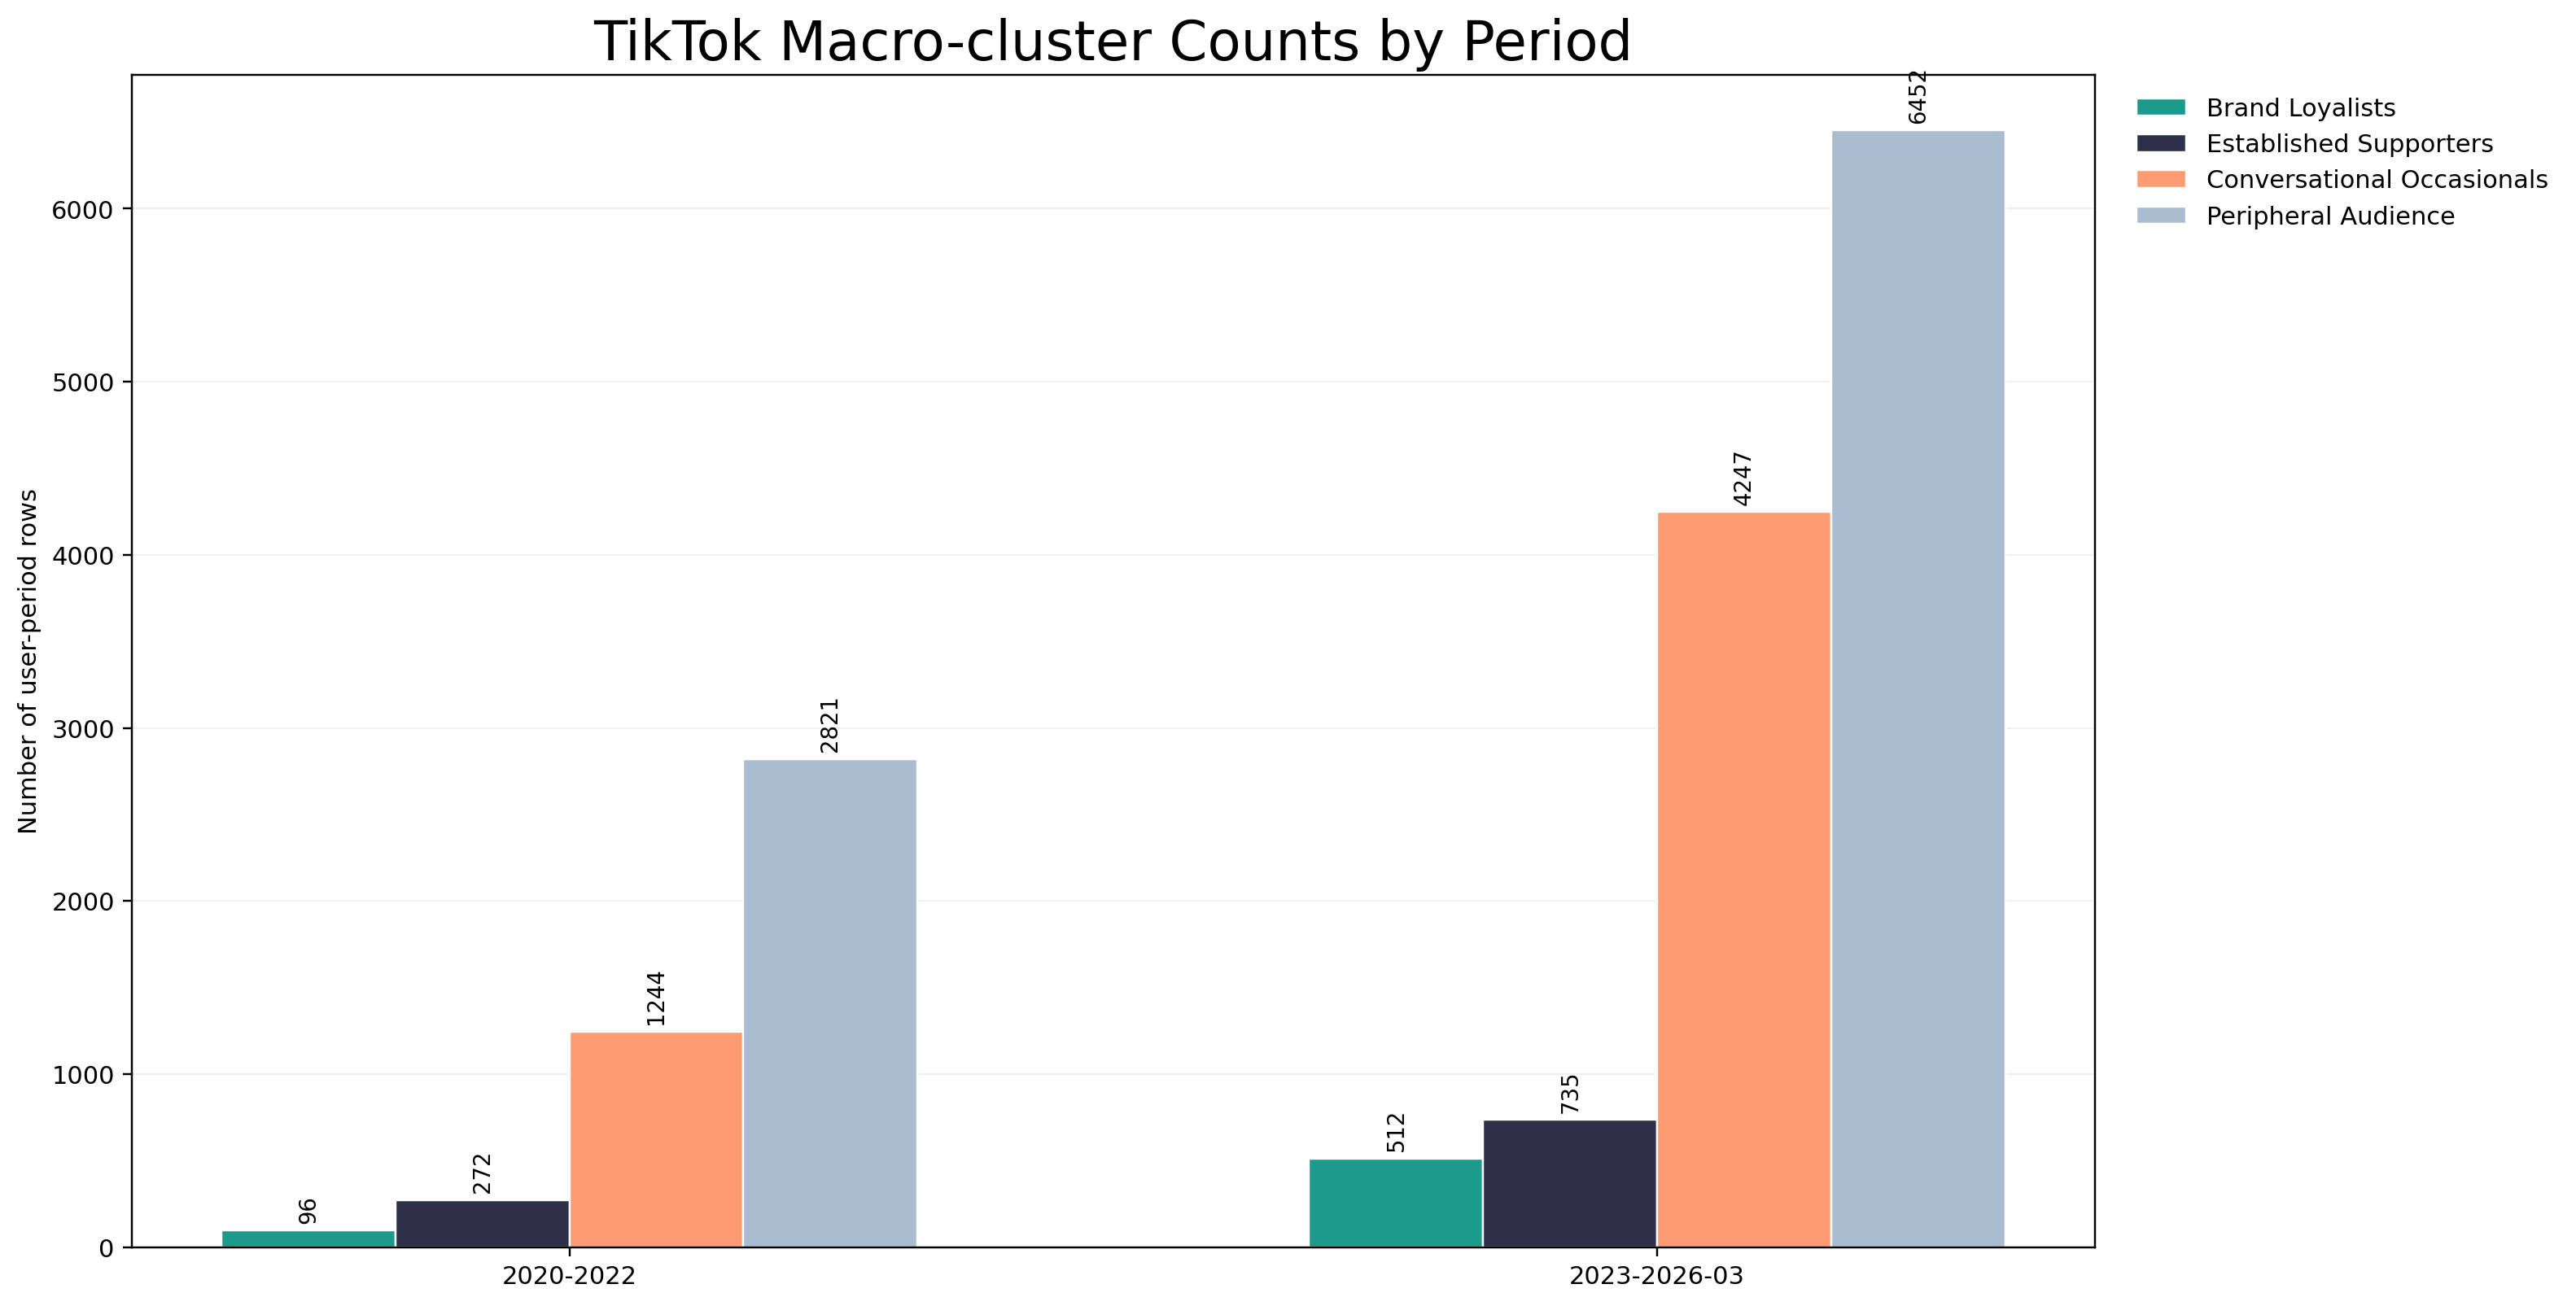

In [15]:
display(Image(filename=str(MACRO_CLUSTER_BAR_PLOT)))


We then switch from counts to composition and plot one pie chart per triennium.

This second visual is useful for comparing the relative cluster mix within each period, independently of the fact that the two triennia have different total numbers of active user-period rows.

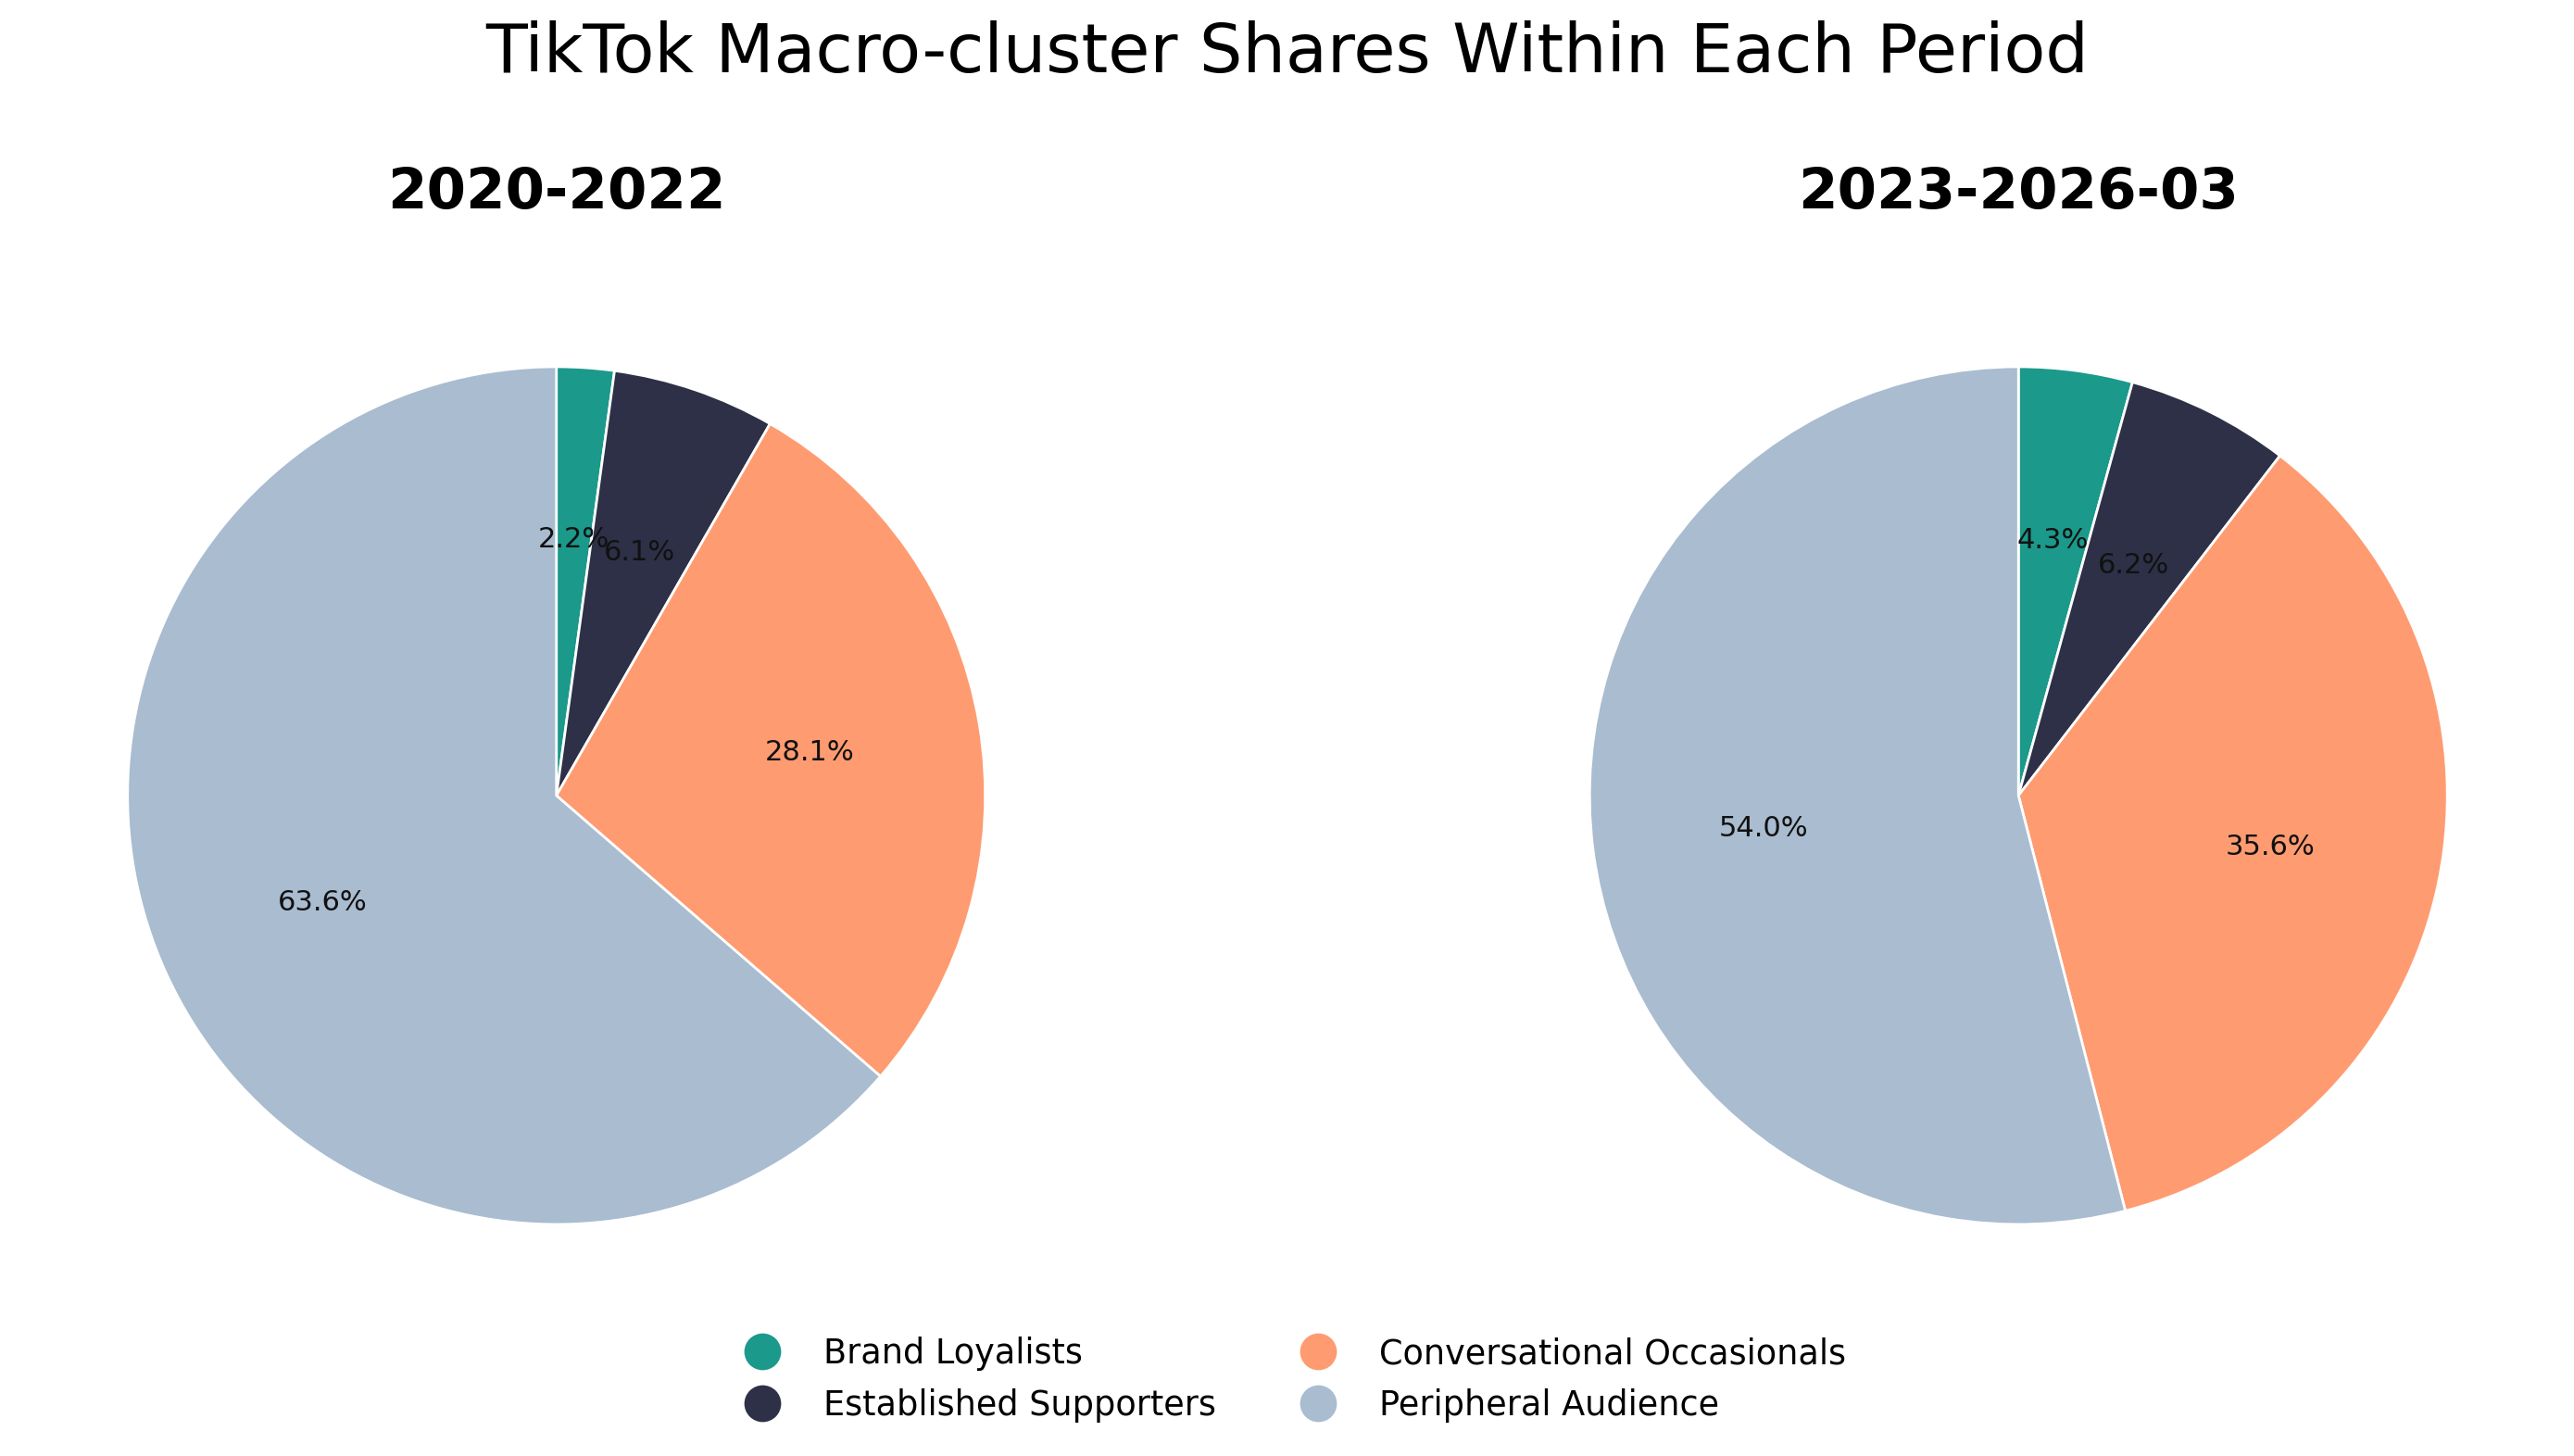

In [16]:
display(Image(filename=str(MACRO_CLUSTER_PIE_PLOT)))


## Plot macro-cluster radar charts by period

We compare the two period profiles within each macro-cluster using globally scaled metrics and an inverted recency axis for interpretability. Because TikTok uses a binary tenure proxy, the radar chart uses the mean share of `tenure_binary = 1` within each cluster-period profile.


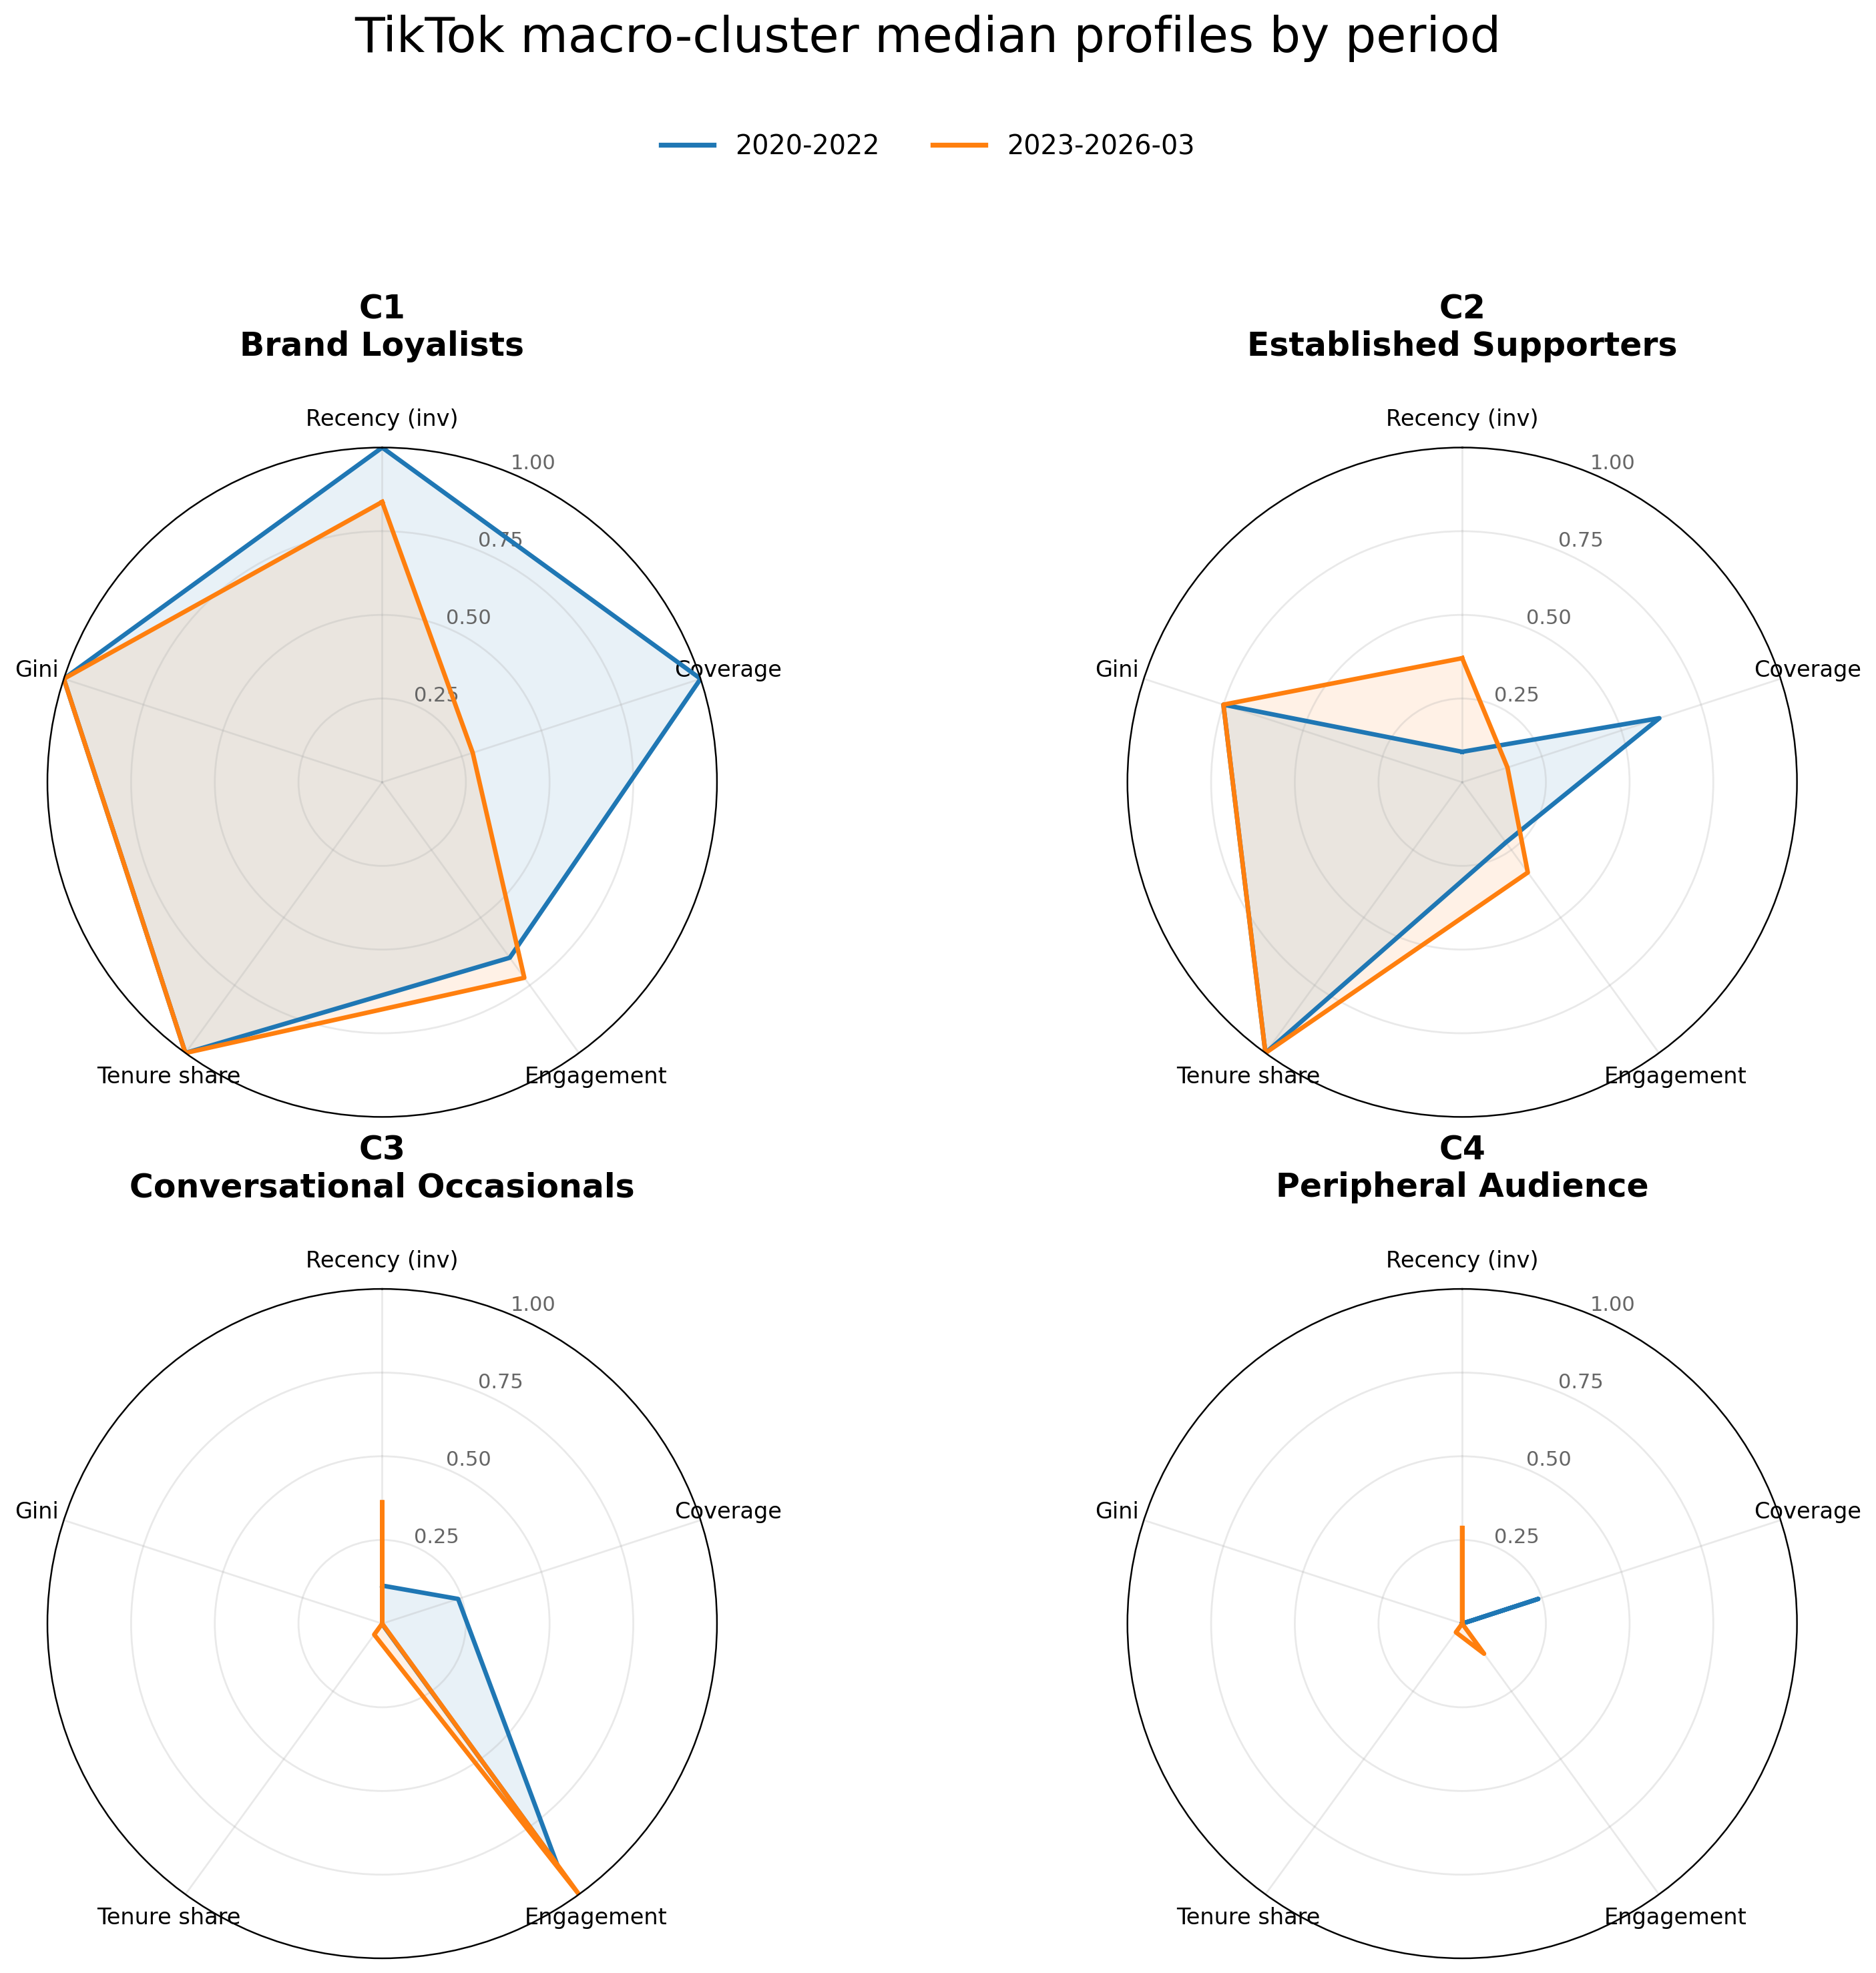

,macro_cluster,cluster_order,macro_cluster_name,cluster_label,period_label,period_index,recency,coverage,engagement,tenure_binary_share,gini,recency_scaled,coverage_scaled,engagement_scaled,tenure_binary_share_scaled,gini_scaled,recency_inverted_scaled
0,C1,1,Brand Loyalists,C1 Brand Loyalists,2020-2022,1,0.177778,0.033333,7.833334,1.000000,0.666667,0.000000,1.000000,0.648148,1.000000,1.00,1.000000
1,C1,1,Brand Loyalists,C1 Brand Loyalists,2023-2026-03,2,0.257261,0.012448,8.500000,1.000000,0.666667,0.162579,0.284368,0.722222,1.000000,1.00,0.837421
2,C2,2,Established Supporters,C2 Established Supporters,2020-2022,1,0.622222,0.022222,4.000000,1.000000,0.500000,0.909090,0.619278,0.222222,1.000000,0.75,0.090910
3,C2,2,Established Supporters,C2 Established Supporters,2023-2026-03,2,0.485477,0.008299,5.000000,1.000000,0.500000,0.629384,0.142201,0.333333,1.000000,0.75,0.370616
4,C3,3,Conversational Occasionals,C3 Conversational Occasionals,2020-2022,1,0.611111,0.011111,10.000000,0.008039,0.000000,0.886363,0.238555,0.888889,0.000956,0.00,0.113637


In [17]:
RADAR_DIR = OUTPUT_DIR / "cluster_radar_plots_nonoverlapping_3y"
RADAR_DIR.mkdir(parents=True, exist_ok=True)

RADAR_RAW_OUTPUT = RADAR_DIR / "tk_nonoverlapping_3y_macro_cluster_period_profiles_raw.csv"
RADAR_SCALED_OUTPUT = RADAR_DIR / "tk_nonoverlapping_3y_macro_cluster_period_profiles_scaled.csv"
RADAR_PLOT_OUTPUT = RADAR_DIR / "tk_nonoverlapping_3y_macro_cluster_radar_by_period.png"

RADAR_PERIOD_COLORS = {
    "2020-2022": "#1f77b4",
    "2023-2026-03": "#ff7f0e",
}
RADAR_LABELS = {
    "recency_inverted_scaled": "Recency (inv)",
    "coverage_scaled": "Coverage",
    "engagement_scaled": "Engagement",
    "tenure_binary_share_scaled": "Tenure share",
    "gini_scaled": "Gini",
}
RADAR_PLOT_COLUMNS = list(RADAR_LABELS.keys())
RADAR_RAW_VARIABLES = ["recency", "coverage", "engagement", "tenure_binary_share", "gini"]

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

if "macro_assignment" not in globals():
    macro_assignment = pd.read_csv(MACRO_CLUSTER_ASSIGNMENT_OUTPUT, low_memory=False)
if "macro_summary" not in globals():
    macro_summary = pd.read_csv(MACRO_CLUSTER_SUMMARY_OUTPUT, low_memory=False)

if "value_rank" in macro_summary.columns:
    radar_cluster_order = macro_summary.sort_values("value_rank")["macro_cluster"].tolist()
else:
    radar_cluster_order = sorted(macro_summary["macro_cluster"].dropna().unique(), key=lambda value: int(value[1:]))
radar_cluster_name_lookup = dict(macro_summary[["macro_cluster", "macro_cluster_name"]].itertuples(index=False, name=None))

radar_period_order = (
    macro_assignment[["period_label", "period_index"]]
    .drop_duplicates()
    .sort_values("period_index")["period_label"]
    .tolist()
)

radar_raw = (
    macro_assignment.groupby(["macro_cluster", "macro_cluster_name", "period_label", "period_index"], sort=False)
    .agg(
        recency=("recency", "median"),
        coverage=("coverage", "median"),
        engagement=("engagement", "median"),
        tenure_binary_share=("tenure_binary", "mean"),
        gini=("gini", "median"),
    )
    .reset_index()
)
radar_raw["cluster_order"] = radar_raw["macro_cluster"].str[1:].astype(int)
radar_raw["cluster_label"] = radar_raw["macro_cluster"] + " " + radar_raw["macro_cluster_name"]
radar_raw = radar_raw.sort_values(["cluster_order", "period_index"]).reset_index(drop=True)
radar_raw.to_csv(RADAR_RAW_OUTPUT, index=False, encoding="utf-8-sig")

radar_scaled = radar_raw.copy()
for column in RADAR_RAW_VARIABLES:
    values = radar_scaled[column].to_numpy(dtype=float)
    min_value = float(np.min(values))
    max_value = float(np.max(values))
    if np.isclose(min_value, max_value):
        scaled_values = np.ones_like(values, dtype=float) * 0.5
    else:
        scaled_values = (values - min_value) / (max_value - min_value)
    radar_scaled[f"{column}_scaled"] = scaled_values

radar_scaled["recency_inverted_scaled"] = 1.0 - radar_scaled["recency_scaled"]

export_columns = [
    "macro_cluster",
    "cluster_order",
    "macro_cluster_name",
    "cluster_label",
    "period_label",
    "period_index",
    *RADAR_RAW_VARIABLES,
    *(f"{column}_scaled" for column in RADAR_RAW_VARIABLES),
    "recency_inverted_scaled",
]
radar_scaled[export_columns].to_csv(RADAR_SCALED_OUTPUT, index=False, encoding="utf-8-sig")

angles = np.linspace(0, 2 * np.pi, len(RADAR_PLOT_COLUMNS), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(15, 13), subplot_kw={"polar": True})
axes = axes.ravel()

for axis, cluster in zip(axes, radar_cluster_order):
    cluster_subset = radar_scaled.loc[radar_scaled["macro_cluster"] == cluster].sort_values("period_index")
    for period_label in radar_period_order:
        period_row = cluster_subset.loc[cluster_subset["period_label"] == period_label]
        if period_row.empty:
            continue
        values = period_row.iloc[0][RADAR_PLOT_COLUMNS].to_numpy(dtype=float).tolist()
        values += values[:1]
        color = RADAR_PERIOD_COLORS[period_label]
        axis.plot(angles, values, color=color, linewidth=2.2, label=period_label)
        axis.fill(angles, values, color=color, alpha=0.10)

    axis.set_theta_offset(np.pi / 2)
    axis.set_theta_direction(-1)
    axis.set_xticks(angles[:-1])
    axis.set_xticklabels([RADAR_LABELS[column] for column in RADAR_PLOT_COLUMNS], fontsize=11)
    axis.set_ylim(0, 1)
    axis.set_yticks([0.25, 0.50, 0.75, 1.00])
    axis.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=10, color="#666666")
    axis.grid(alpha=0.28, linewidth=0.9)
    axis.set_title(f"{cluster}\n{radar_cluster_name_lookup[cluster]}", y=1.12, fontsize=16, fontweight="bold")

for axis in axes[len(radar_cluster_order):]:
    axis.remove()

legend_handles = [
    plt.Line2D([0], [0], color=RADAR_PERIOD_COLORS[period_label], linewidth=2.4, label=period_label)
    for period_label in radar_period_order
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=max(len(radar_period_order), 1), frameon=False, fontsize=13)
fig.suptitle("TikTok macro-cluster median profiles by period", fontsize=24, y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(RADAR_PLOT_OUTPUT, dpi=220, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(RADAR_PLOT_OUTPUT)))
radar_scaled[export_columns].head()
